In [ ]:
# 1. Install Dependencies
!pip install kaggle pillow numpy pandas matplotlib seaborn tqdm opencv-python-headless scikit-learn

# 2. Import Libraries
import os
import io
import shutil
import hashlib
import warnings
import zipfile
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2

from PIL import Image, ImageStat
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from pathlib import Path

# Matikan warning visualisasi
warnings.filterwarnings('ignore')
print("Setup & Import selesai!")

Setup & Import selesai!


# Pertanyaan Bisnis yang Dapat Diukur

**1. Pertanyaan Bisnis 1: Distribusi & Risiko Class Imbalance**
* **Pertanyaan:** Bagaimana rasio perbandingan volume gambar tiap kategori sampah utama (Organik, Anorganik, B3), dan kategori mana yang berpotensi mengalami penurunan performa klasifikasi akibat ketidakseimbangan data (*class imbalance*)?
* **Metrik yang Diukur:** Jumlah gambar per kelas (Organik, Anorganik, B3) dan rasio perbandingannya.
* **Eksekusi EDA & Visualisasi:** *Bar Chart* distribusi kelas dan *Pie Chart* proporsi.

**2. Pertanyaan Bisnis 2: Karakteristik Visual Gambar**
* **Pertanyaan:** Bagaimana karakteristik kualitas visual gambar (distribusi resolusi, kecerahan/brightness, dan tingkat kejelasan/sharpness) dari dataset sampah yang dikumpulkan, dan apakah karakteristik tersebut konsisten di setiap kelas?
* **Metrik yang Diukur:** Dimensi gambar (lebar x tinggi), nilai kecerahan rata-rata, dan skor ketajaman (Laplacian variance).
* **Eksekusi EDA & Visualisasi:** *Histogram*, *Box Plot*, dan *Scatter Plot*.

**3. Pertanyaan Bisnis 3: Konsistensi & Kesiapan Data untuk Training**
* **Pertanyaan:** Berapa persentase gambar yang perlu dieliminasi akibat masalah kualitas (corrupt, resolusi rendah, duplikat, dll), dan apakah dataset akhir yang tersisa sudah cukup representatif dan seimbang untuk melatih model klasifikasi CNN secara andal?
* **Metrik yang Diukur:** Jumlah gambar yang dieliminasi per kategori masalah dan distribusi final dataset bersih.
* **Eksekusi EDA & Visualisasi:** *Summary table* dan *stacked bar chart* perbandingan sebelum-sesudah cleaning.

# Data Wrangling
## Tahap 1: Data Gathering (Pengumpulan Data Mentah)

**Tujuan:**
Mengumpulkan dataset gambar dari dua sumber Kaggle yang berbeda, lalu menyeleksi folder-folder yang relevan untuk membentuk 3 kelas target utama: **Organik**, **Anorganik**, dan **B3 (Bahan Berbahaya dan Beracun)**.

**Sumber Data & Link Dataset:**
1. **Kaggle ([Dataset Sampah Organik dan Anorganik — eldadvikorian](https://www.kaggle.com/datasets/eldadvikorian/dataset-sampah-organik-dan-anorganik)):** Digunakan sebagai representasi kelas **Organik** dan **Anorganik**. Dataset ini merupakan dataset capstone Bangkit yang berisi gambar sampah organik (sisa makanan, daun, bahan biodegradable) dan anorganik (plastik, kertas, logam, kaca, dan material non-biodegradable lainnya).
2. **Kaggle ([Waste Datasets](https://www.kaggle.com/datasets/salam035/waste-datasets)):** Digunakan sebagai representasi kelas **B3**. Dataset ini berisi berbagai jenis limbah berbahaya dan beracun yang diseleksi dari folder `Dataset_secondStage` dan `Dataset_ThirdStage`.

**Seleksi Folder Dataset B3 dari `salam035/waste-datasets`:**
- `Dataset_secondStage`: G_Medical Waste, H_E Waste, I_Hazardous Waste
- `Dataset_ThirdStage`: W_Masks, Y_Medicine and Medicine strip, Z_A_A_Syringe, Z_A_Diaper, Z_B_Electrical Cable, Z_C_Electronic Chip, Z_D_Laptops, Z_E_Small Appliances, Z_F_Smartphones, Z_G_Battery, Z_H_Thermometer, Z_I_Cigarette Butt, Z_J_Pesticidebottle, Z_K_Spray cans

**Insight Pengumpulan Awal:**
Pengumpulan data dari dua sumber Kaggle ini dilakukan untuk membangun dataset yang komprehensif dan representatif terhadap skenario nyata pengelolaan sampah:
* **Organik & Anorganik (Kaggle 1 — eldadvikorian):** Dataset ini dipilih karena merupakan dataset capstone Bangkit yang dirancang khusus untuk klasifikasi sampah di konteks Indonesia, dengan cakupan gambar yang lebih beragam dan representatif dibanding dataset generik.
* **B3 (Kaggle 2 - Selektif):** Pemilihan folder secara selektif dilakukan karena tidak semua folder dalam dataset tersebut relevan untuk kategori B3 menurut regulasi pengelolaan limbah Indonesia (PP No. 22 Tahun 2021). Folder-folder yang dipilih mencakup limbah medis, elektronik, dan bahan kimia berbahaya yang secara hukum memerlukan penanganan khusus.

In [ ]:
# ==============================================================================
# KONFIGURASI KAGGLE API — Token-Based Authentication (Format Baru KGAT)
# Kaggle kini menggunakan KGAT token, bukan file kaggle.json
# Token didapat dari: https://www.kaggle.com/settings → API → Create New Token
#
# ⚠️  PENTING — KEAMANAN TOKEN:
# JANGAN hardcode token langsung di notebook. Gunakan salah satu cara berikut:
#   1. Google Colab  : Simpan di Colab Secrets (kunci 'KAGGLE_TOKEN')
#                      Menu: Kunci 🔑 di sidebar kiri → Add new secret
#   2. Lokal/Kaggle  : Set environment variable sebelum menjalankan notebook:
#                      export KAGGLE_TOKEN="KGAT_xxx..." (di terminal)
# ==============================================================================

import os

# --- AMBIL TOKEN DARI COLAB SECRETS ATAU ENVIRONMENT VARIABLE ---
KAGGLE_TOKEN = None

# Coba Colab Secrets terlebih dahulu
try:
    from google.colab import userdata
    KAGGLE_TOKEN = userdata.get('KAGGLE_TOKEN')
    print("[v] Token berhasil diambil dari Google Colab Secrets.")
except Exception:
    pass

# Fallback: ambil dari environment variable
if not KAGGLE_TOKEN:
    KAGGLE_TOKEN = os.environ.get('KAGGLE_TOKEN')
    if KAGGLE_TOKEN:
        print("[v] Token berhasil diambil dari environment variable KAGGLE_TOKEN.")

if not KAGGLE_TOKEN:
    raise ValueError(
        "[!] KAGGLE_TOKEN tidak ditemukan!\n"
        "    Simpan token di Colab Secrets dengan kunci 'KAGGLE_TOKEN', "
        "atau set environment variable KAGGLE_TOKEN sebelum menjalankan notebook."
    )

# --- SETUP OTOMATIS: Buat folder & simpan access token ---
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

token_path = os.path.join(kaggle_dir, "access_token")
with open(token_path, "w") as f:
    f.write(KAGGLE_TOKEN)
os.chmod(token_path, 0o600)

# --- SET ENVIRONMENT VARIABLE (wajib agar kaggle CLI & library mengenali token) ---
os.environ["KAGGLE_API_TOKEN"] = KAGGLE_TOKEN

# --- VERIFIKASI SETUP ---
print("[v] Token Kaggle berhasil dikonfigurasi!")
print(f"    Path  : {token_path}")
print(f"    Token : {KAGGLE_TOKEN[:8]}...{KAGGLE_TOKEN[-4:]} (disembunyikan sebagian)")
print()

# --- TEST KONEKSI KE KAGGLE API ---
import subprocess
result = subprocess.run(
    ["kaggle", "competitions", "list"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("[v] Koneksi ke Kaggle API berhasil!")
    # Cetak 3 baris pertama output sebagai bukti koneksi
    lines = result.stdout.strip().split('\n')
    for line in lines[:3]:
        print(f"    {line}")
else:
    print("[!] Koneksi gagal. Periksa token atau perbarui ke token terbaru dari Kaggle Settings.")
    print(result.stderr[:300])


[v] Token berhasil diambil dari Google Colab Secrets.
[v] Token Kaggle berhasil dikonfigurasi!
    Path  : /root/.kaggle/access_token
    Token : KGAT_b87...9550 (disembunyikan sebagian)

[v] Koneksi ke Kaggle API berhasil!
    ref                                                                              deadline             category         reward  teamCount  userHasEntered  
    -------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
    https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  


In [ ]:
# ==============================================================================
# TAHAP 1: DATA GATHERING
# Mengunduh dan mengorganisasi dataset dari Kaggle
# ==============================================================================

import os
import shutil
import zipfile
from pathlib import Path

# --- KONFIGURASI FOLDER ---
RAW_DIR        = "raw_datasets"
ORGANIK_RAW    = os.path.join(RAW_DIR, "organik")
ANORGANIK_RAW  = os.path.join(RAW_DIR, "anorganik")
B3_RAW         = os.path.join(RAW_DIR, "b3")

os.makedirs(ORGANIK_RAW,   exist_ok=True)
os.makedirs(ANORGANIK_RAW, exist_ok=True)
os.makedirs(B3_RAW,        exist_ok=True)

print("=" * 60)
print(" MULAI PROSES DATA GATHERING ")
print("=" * 60)

# --- 1. UNDUH DATASET ORGANIK & ANORGANIK ---
# Sumber: https://www.kaggle.com/datasets/eldadvikorian/dataset-sampah-organik-dan-anorganik
print("\n[1] Mengunduh dataset Organik & Anorganik (eldadvikorian)...")
!kaggle datasets download -d eldadvikorian/dataset-sampah-organik-dan-anorganik -p {RAW_DIR} --unzip
print("    [v] Dataset Organik & Anorganik berhasil diunduh.")

# --- 2. UNDUH DATASET B3 ---
print("\n[2] Mengunduh dataset B3 (Waste Datasets)...")
!kaggle datasets download -d salam035/waste-datasets -p {RAW_DIR} --unzip
print("    [v] Dataset B3 berhasil diunduh.")

# --- CETAK STRUKTUR DIREKTORI ---
print("\n[3] Struktur direktori dataset mentah:")
for root, dirs, files_list in os.walk(RAW_DIR):
    level = root.replace(RAW_DIR, '').count(os.sep)
    if level > 3:
        continue
    indent = '  ' * level
    n_files = len([f for f in files_list if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))])
    folder_name = os.path.basename(root)
    if n_files > 0:
        print(f"{indent}{folder_name}/ ({n_files} gambar)")
    else:
        print(f"{indent}{folder_name}/")

print("\n" + "=" * 60)
print(" GATHERING SELESAI ")
print("=" * 60)

 MULAI PROSES DATA GATHERING 

[1] Mengunduh dataset Organik & Anorganik (eldadvikorian)...
Dataset URL: https://www.kaggle.com/datasets/eldadvikorian/dataset-sampah-organik-dan-anorganik
License(s): unknown
100% 427M/427M [00:07<00:00, 57.6MB/s]

    [v] Dataset Organik & Anorganik berhasil diunduh.

[2] Mengunduh dataset B3 (Waste Datasets)...
Dataset URL: https://www.kaggle.com/datasets/salam035/waste-datasets
License(s): MIT
100% 8.20G/8.20G [01:22<00:00, 107MB/s]

    [v] Dataset B3 berhasil diunduh.

[3] Struktur direktori dataset mentah:
raw_datasets/
  dataset/
    DATASET/
      TEST/
      TRAIN/
  b3/
  Dataset_ThirdStage/
    Dataset/
      Z_K_Spray cans/ (400 gambar)
      R_Plastic Cups/ (405 gambar)
      H_Porcelin/ (813 gambar)
      G_Brown Glass/ (607 gambar)
      S_Tetra Pak/ (842 gambar)
      Z_A_A_Syringe/ (405 gambar)
      Z_B_Electrical Cables/ (553 gambar)
      Z_I_Cigarette Butt/ (97 gambar)
      M_Metal Containers/ (437 gambar)
      C_Cardboard/ (2035 

In [ ]:
# ==============================================================================
# PROSES PEMBERSIHAN / REPLACE TIAP RUN
# Menghapus folder lama jika ada, lalu membuatnya kembali dalam keadaan kosong 0
# ==============================================================================
import shutil
import os
from pathlib import Path

print("[*] Mengosongkan folder penampungan lama (Proses Replace)...")
for folder_path in [ORGANIK_RAW, ANORGANIK_RAW, B3_RAW]:
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)  # Hapus folder beserta isinya
    os.makedirs(folder_path, exist_ok=True)  # Buat kembali folder baru yang kosong
print("[v] Folder ORGANIK, ANORGANIK, dan B3 berhasil di-reset ke 0 gambar.\n")

# ==============================================================================
# SELEKSI & ORGANISASI FOLDER B3
# Memindahkan hanya folder-folder yang relevan dari dataset waste-datasets
# ==============================================================================

# Folder B3 yang dipilih dari Dataset_secondStage
B3_SECOND_STAGE = [
    "G_Medical Waste",
    "H_E Waste",
    "I_Hazardous Waste",
]

# Folder B3 yang dipilih dari Dataset_ThirdStage
B3_THIRD_STAGE = [
    "W_Masks",
    "Y_Medicine and Medicine strip",
    "Z_A_A_Syringe",
    "Z_A_Diaper",
    "Z_B_Electrical Cable",
    "Z_C_Electronic Chip",
    "Z_D_Laptops",
    "Z_E_Small Appliances",
    "Z_F_Smartphones ",
    "Z_G_Battery",
    "Z_H_Thermometer",
    "Z_I_Cigarette Butt",
    "Z_J_Pesticidebottle",
    "Z_K_Spray cans",
]

VALID_IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff')

def copy_images_from_folder(src_folder, dst_folder, prefix=""):
    """Menyalin semua gambar dari src_folder ke dst_folder secara rekursif."""
    copied = 0
    if not os.path.exists(src_folder):
        print(f"    [!] Folder tidak ditemukan: {src_folder}")
        return 0
    for root, _, files_list in os.walk(src_folder):
        for fname in files_list:
            if fname.lower().endswith(VALID_IMG_EXT):
                src_path = os.path.join(root, fname)
                new_name = f"{prefix}_{fname}" if prefix else fname
                # Tambahkan counter jika nama duplikat
                dst_path = os.path.join(dst_folder, new_name)
                counter = 1
                while os.path.exists(dst_path):
                    base, ext = os.path.splitext(new_name)
                    dst_path = os.path.join(dst_folder, f"{base}_{counter}{ext}")
                    counter += 1
                shutil.copy2(src_path, dst_path)
                copied += 1
    return copied

print("[*] Mengorganisasi dataset B3 dari Dataset_secondStage...")
total_second = 0
BASE_WASTE = RAW_DIR  # direktori hasil unduhan

for folder_name in B3_SECOND_STAGE:
    found = list(Path(BASE_WASTE).rglob(folder_name))
    if found:
        prefix = folder_name.replace(" ", "_").replace("/", "_")
        n = copy_images_from_folder(str(found[0]), B3_RAW, prefix=prefix)
        print(f"    [v] {folder_name}: {n} gambar disalin")
        total_second += n
    else:
        print(f"    [!] {folder_name}: tidak ditemukan")

print(f"\n[*] Mengorganisasi dataset B3 dari Dataset_ThirdStage...")
total_third = 0
for folder_name in B3_THIRD_STAGE:
    found = list(Path(BASE_WASTE).rglob(folder_name.strip()))
    if found:
        prefix = folder_name.strip().replace(" ", "_").replace("/", "_")
        n = copy_images_from_folder(str(found[0]), B3_RAW, prefix=prefix)
        print(f"    [v] {folder_name.strip()}: {n} gambar disalin")
        total_third += n
    else:
        print(f"    [!] {folder_name.strip()}: tidak ditemukan")

# Hitung gambar Organik & Anorganik
def count_images(folder):
    count = 0
    for root, _, files_list in os.walk(folder):
        count += sum(1 for f in files_list if f.lower().endswith(VALID_IMG_EXT))
    return count

# ==============================================================================
# SUMBER DATASET ORGANIK & ANORGANIK
# Organik: Hanya eldadvikorian (O)
# Anorganik: eldadvikorian (R) + Dataset_secondStage (B_Recyclable Waste)
# ==============================================================================

print("\n[*] Mengumpulkan folder Organik & Anorganik sesuai kustomisasi...")

organik_folders   = []
anorganik_folders = []

base_dataset_path = Path(RAW_DIR)

# 1. Ambil folder Organik (HANYA milik eldadvikorian yang namanya 'O' atau 'o')
for p in base_dataset_path.rglob('*'):
    if p.is_dir() and p.name.lower() == 'o':
        # Proteksi agar tidak mengambil dari dataset stage lainnya
        if "dataset_thirdstage" not in str(p).lower() and "dataset_firststage" not in str(p).lower() and "dataset_secondstage" not in str(p).lower():
            organik_folders.append(p)

# 2. Ambil folder Anorganik (Milik eldadvikorian 'R' DAN B_Recyclable Waste)
for p in base_dataset_path.rglob('*'):
    if p.is_dir():
        # Kondisi A: Folder 'R' dari eldadvikorian
        if p.name.lower() == 'r':
            if "dataset_thirdstage" not in str(p).lower() and "dataset_firststage" not in str(p).lower() and "dataset_secondstage" not in str(p).lower():
                anorganik_folders.append(p)

        # Kondisi B: Folder 'B_Recyclable Waste' dari Dataset_secondStage
        elif p.name == 'B_Recyclable Waste':
            anorganik_folders.append(p)

# Cetak untuk memastikan folder yang didapat sudah benar
print(f"\n[v] Folder terdeteksi sebagai Organik ({len(organik_folders)} folder):")
for f in organik_folders:
    print(f"      + {f.relative_to(RAW_DIR)}")

print(f"\n[v] Folder terdeteksi sebagai Anorganik ({len(anorganik_folders)} folder):")
for f in anorganik_folders:
    print(f"      + {f.relative_to(RAW_DIR)}")


# ==============================================================================
# PROSES MENYALIN GAMBAR KE FOLDER UTAMA (RAW)
# ==============================================================================

print("\n[*] Menyalin gambar Organik ke folder utama...")
for folder in organik_folders:
    # Menggunakan prefix nama parent-nya (misal: TRAIN atau TEST) agar membedakan file
    prefix = folder.parent.name
    n = copy_images_from_folder(str(folder), ORGANIK_RAW, prefix=prefix)
    print(f"    {folder.relative_to(RAW_DIR)}: {n} gambar disalin")

print("\n[*] Menyalin gambar Anorganik ke folder utama...")
for folder in anorganik_folders:
    # Jika folder B_Recyclable Waste, gunakan nama foldernya langsung sebagai prefix
    prefix = folder.name if folder.name == 'B_Recyclable Waste' else folder.parent.name
    n = copy_images_from_folder(str(folder), ANORGANIK_RAW, prefix=prefix)
    print(f"    {folder.relative_to(RAW_DIR)}: {n} gambar disalin")


# ==============================================================================
# HITUNG RINGKASAN DATA AKHIR
# ==============================================================================
n_organik   = count_images(ORGANIK_RAW)
n_anorganik = count_images(ANORGANIK_RAW)
n_b3        = count_images(B3_RAW)

print("\n" + "=" * 60)
print(" RINGKASAN GATHERING (SEBELUM CLEANING) ")
print("=" * 60)
print(f"  Organik   : {n_organik:>6} gambar")
print(f"  Anorganik : {n_anorganik:>6} gambar")
print(f"  B3        : {n_b3:>6} gambar (dari {total_second + total_third} total disalin)")
print(f"  TOTAL RAW : {n_organik + n_anorganik + n_b3:>6} gambar")
print("=" * 60)

[*] Mengosongkan folder penampungan lama (Proses Replace)...
[v] Folder ORGANIK, ANORGANIK, dan B3 berhasil di-reset ke 0 gambar.

[*] Mengorganisasi dataset B3 dari Dataset_secondStage...
    [v] G_Medical Waste: 3648 gambar disalin
    [v] H_E Waste: 4391 gambar disalin
    [v] I_Hazardous Waste: 2345 gambar disalin

[*] Mengorganisasi dataset B3 dari Dataset_ThirdStage...
    [v] W_Masks: 400 gambar disalin
    [!] Y_Medicine and Medicine strip: tidak ditemukan
    [v] Z_A_A_Syringe: 405 gambar disalin
    [v] Z_A_Diaper: 778 gambar disalin
    [!] Z_B_Electrical Cable: tidak ditemukan
    [!] Z_C_Electronic Chip: tidak ditemukan
    [v] Z_D_Laptops: 398 gambar disalin
    [v] Z_E_Small Appliances: 740 gambar disalin
    [v] Z_F_Smartphones: 219 gambar disalin
    [v] Z_G_Battery: 1989 gambar disalin
    [v] Z_H_Thermometer: 908 gambar disalin
    [v] Z_I_Cigarette Butt: 97 gambar disalin
    [v] Z_J_Pesticidebottle: 940 gambar disalin
    [v] Z_K_Spray cans: 400 gambar disalin

[*]

## Tahap 2: Data Assessing (Evaluasi Kualitas Dataset Gambar)

**Tujuan:**
Melakukan inspeksi menyeluruh terhadap dataset gambar mentah untuk mengidentifikasi berbagai anomali fisik dan kualitas sebelum masuk ke tahap *cleaning*. Berbeda dengan *object detection* yang juga mengecek anotasi *bounding box*, untuk **image classification** fokus penilaian murni pada kualitas intrinsik gambar itu sendiri.

**8 Metrik Evaluasi Kualitas Gambar:**
1. **Corrupt / Gagal Dimuat:** Gambar yang tidak dapat dibuka sama sekali menggunakan library Pillow — menandakan file rusak atau terenkripsi.
2. **Resolusi < 100px:** Gambar dengan lebar atau tinggi di bawah 100 piksel — terlalu kecil untuk diekstrak fitur visualnya secara andal oleh CNN.
3. **Kualitas Ekstrem (Brightness):** Gambar yang terlalu gelap (mean brightness < 20) atau terlalu terang/silau (mean brightness > 235) — fitur warna dan tekstur akan hilang.
4. **Duplikat Internal (MD5 Hash):** Gambar identik di dalam kelas yang sama — menyebabkan overfitting dan inflasi jumlah data.
5. **Leakage Lintas Kelas (Cross-Class Duplicate):** Gambar yang sama persis muncul di lebih dari satu kelas — hanya dicatat sebagai informasi. Gambar akan **dipertahankan di kelas pertama** yang menemukannya dan dihapus dari kelas duplikatnya (bukan dihapus total). Ini penting agar satu kelas tidak habis hanya karena overlap dataset sumber.
6. **Gambar Blur / Tidak Tajam:** Gambar dengan nilai *Laplacian variance* di bawah ambang batas — fitur tepi dan tekstur yang dibutuhkan CNN akan terlalu lemah.
7. **Mode Warna Non-RGB:** Gambar dalam mode RGBA, Grayscale, Palette, atau lainnya — perlu dikonversi agar kompatibel dengan input CNN standar (3 channel).
8. **Variasi Resolusi Ekstrem:** Identifikasi rentang dimensi gambar — diperlukan untuk menentukan strategi *resize* yang tepat sebelum masuk pipeline training.

**Catatan Khusus — Penanganan Outlier:**
Selain 8 metrik di atas, dilakukan juga pendeteksian *outlier statistik* berbasis nilai piksel menggunakan metode **IQR (Interquartile Range)** pada fitur brightness dan sharpness. Gambar yang nilai statistiknya jauh di luar distribusi normal kelas (lebih dari 3x IQR) **tidak dihapus**, melainkan hanya **ditandai (flag)** untuk keperluan analisis dan pelaporan. Penghapusan outlier pada data gambar berisiko menghilangkan terlalu banyak data valid, sehingga strategi yang dipilih adalah membiarkannya tetap ada dalam dataset sambil memastikan augmentasi yang tepat pada tahap training.

In [ ]:
# ==============================================================================
# TAHAP 2: DATA ASSESSING
# Evaluasi 8 metrik kualitas gambar + deteksi outlier statistik
# ==============================================================================

from PIL import Image, ImageStat
import hashlib
import cv2
import numpy as np
from tqdm import tqdm

# --- KONFIGURASI AMBANG BATAS ---
MIN_RESOLUTION  = 100     # piksel (lebar DAN tinggi minimal)
MIN_BRIGHTNESS  = 20      # terlalu gelap
MAX_BRIGHTNESS  = 235     # terlalu terang / overexposed
BLUR_THRESHOLD  = 50.0    # nilai Laplacian variance — di bawah ini = blur
                          # [Catatan] Threshold 50 dipilih setelah analisis distribusi
                          # Laplacian per kelas (lihat cell analisis distribusi di bawah).
                          # Gambar sampah in-the-wild sering memiliki Lap < 80 tapi masih valid;
                          # threshold 50 membuang hanya gambar yang benar-benar tidak informatif.
OUTLIER_IQR_FACTOR = 3.0  # faktor IQR untuk deteksi outlier

CLASSES = {
    "Organik"  : ORGANIK_RAW,
    "Anorganik": ANORGANIK_RAW,
    "B3"       : B3_RAW,
}

VALID_IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff')

def compute_md5(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def compute_laplacian(img_pil):
    """Menghitung sharpness menggunakan Laplacian variance."""
    img_gray = np.array(img_pil.convert('L'))
    return cv2.Laplacian(img_gray, cv2.CV_64F).var()

# --- INISIALISASI STRUKTUR DATA ---
records = []       # metadata setiap gambar
global_md5 = {}   # hash global lintas kelas untuk deteksi leakage

assess_stats = {
    "corrupt"          : 0,
    "resolusi_kecil"   : 0,
    "ekstrem_cahaya"   : 0,
    "duplikat_internal": 0,
    "leakage_lintas"   : 0,
    "blur"             : 0,
    "non_rgb"          : 0,
}

image_modes = set()
resolutions = set()

print("=" * 60)
print(" MULAI DATA ASSESSING ")
print("=" * 60)

for class_name, class_dir in CLASSES.items():
    print(f"\n[*] Memindai kelas: {class_name} ...")
    class_md5 = {}  # hash per kelas untuk duplikat internal

    img_files = []
    for root, _, files_list in os.walk(class_dir):
        for fname in files_list:
            if fname.lower().endswith(VALID_IMG_EXT):
                img_files.append(os.path.join(root, fname))

    for img_path in tqdm(img_files, desc=f"  Assessing {class_name}"):
        record = {
            "path"      : img_path,
            "class"     : class_name,
            "filename"  : os.path.basename(img_path),
            "md5"       : None,
            "width"     : None,
            "height"    : None,
            "mode"      : None,
            "brightness": None,
            "sharpness" : None,
            "is_corrupt"         : False,
            "is_low_res"         : False,
            "is_extreme_light"   : False,
            "is_internal_dup"    : False,
            "is_cross_class_leak": False,
            "is_blur"            : False,
            "is_non_rgb"         : False,
        }

        # [1] CEK CORRUPT
        try:
            img = Image.open(img_path)
            img.verify()
            img = Image.open(img_path)  # buka ulang setelah verify
        except Exception:
            record["is_corrupt"] = True
            assess_stats["corrupt"] += 1
            records.append(record)
            continue

        # [2] DIMENSI & RESOLUSI
        w, h = img.size
        record["width"]  = w
        record["height"] = h
        resolutions.add((w, h))

        if w < MIN_RESOLUTION or h < MIN_RESOLUTION:
            record["is_low_res"] = True
            assess_stats["resolusi_kecil"] += 1

        # [3] MODE WARNA
        record["mode"] = img.mode
        image_modes.add(img.mode)
        if img.mode != 'RGB':
            record["is_non_rgb"] = True
            assess_stats["non_rgb"] += 1

        # [4] BRIGHTNESS (perlu konversi ke RGB untuk ImageStat)
        try:
            img_rgb = img.convert('RGB')
            stat = ImageStat.Stat(img_rgb)
            brightness = sum(stat.mean) / 3
            record["brightness"] = round(brightness, 2)
            if brightness < MIN_BRIGHTNESS or brightness > MAX_BRIGHTNESS:
                record["is_extreme_light"] = True
                assess_stats["ekstrem_cahaya"] += 1
        except Exception:
            pass

        # [5] SHARPNESS / BLUR (Laplacian)
        try:
            sharpness = compute_laplacian(img)
            record["sharpness"] = round(sharpness, 2)
            if sharpness < BLUR_THRESHOLD:
                record["is_blur"] = True
                assess_stats["blur"] += 1
        except Exception:
            pass

        # [6] MD5 HASH — CEK DUPLIKAT INTERNAL
        md5 = compute_md5(img_path)
        record["md5"] = md5

        if md5 in class_md5:
            # Gambar identik di kelas yang SAMA → hapus (benar-benar duplikat)
            record["is_internal_dup"] = True
            assess_stats["duplikat_internal"] += 1
        else:
            class_md5[md5] = img_path

        # [7] CEK LEAKAGE LINTAS KELAS — STRATEGI FIRST-CLASS-WINS
        # Gambar yang sama di kelas berbeda: PERTAHANKAN di kelas pertama,
        # tandai sebagai leakage hanya pada kemunculan KEDUA dan seterusnya.
        # Ini mencegah satu kelas habis total akibat overlap antar dataset sumber.
        if md5 in global_md5 and global_md5[md5]["class"] != class_name:
            record["is_cross_class_leak"] = True
            assess_stats["leakage_lintas"] += 1
        elif md5 not in global_md5:
            global_md5[md5] = {"path": img_path, "class": class_name}

        records.append(record)

# Buat DataFrame
df_assess = pd.DataFrame(records)

# --- RINGKASAN ASSESSING ---
print("\n" + "=" * 60)
print(" HASIL DATA ASSESSING ")
print("=" * 60)
print(f"Total gambar dipindai       : {len(df_assess):>6}")
print("-" * 60)
print(f"[1] Corrupt / Gagal Dimuat  : {assess_stats['corrupt']:>6}")
print(f"[2] Resolusi < {MIN_RESOLUTION}px         : {assess_stats['resolusi_kecil']:>6}")
print(f"[3] Kualitas Ekstrem Cahaya : {assess_stats['ekstrem_cahaya']:>6}")
print(f"[4] Duplikat Internal       : {assess_stats['duplikat_internal']:>6}")
print(f"[5] Leakage Lintas Kelas    : {assess_stats['leakage_lintas']:>6}")
print(f"    (Kemunculan duplikat ke-2 dst di kelas berbeda — dihapus dari kelas duplikatnya)")
print(f"[6] Gambar Blur             : {assess_stats['blur']:>6} (Laplacian < {BLUR_THRESHOLD})")
print(f"[7] Mode Warna Non-RGB      : {assess_stats['non_rgb']:>6} (dikonversi, tidak dihapus)")
print(f"[8] Variasi Resolusi Unik   : {len(resolutions):>6} ukuran berbeda")
print(f"    Mode warna ditemukan    : {image_modes}")
print("=" * 60)
print("\nDistribusi per Kelas (Sebelum Cleaning):")
print(df_assess['class'].value_counts().to_string())

 MULAI DATA ASSESSING 

[*] Memindai kelas: Organik ...


  Assessing Organik: 100%|██████████| 27932/27932 [00:48<00:00, 581.42it/s]



[*] Memindai kelas: Anorganik ...


  Assessing Anorganik: 100%|██████████| 27550/27550 [01:44<00:00, 264.54it/s]



[*] Memindai kelas: B3 ...


  Assessing B3: 100%|██████████| 17658/17658 [06:28<00:00, 45.48it/s]



 HASIL DATA ASSESSING 
Total gambar dipindai       :  73140
------------------------------------------------------------
[1] Corrupt / Gagal Dimuat  :      0
[2] Resolusi < 100px         :    284
[3] Kualitas Ekstrem Cahaya :   4562
[4] Duplikat Internal       :  33105
[5] Leakage Lintas Kelas    :      2
    (Kemunculan duplikat ke-2 dst di kelas berbeda — dihapus dari kelas duplikatnya)
[6] Gambar Blur             :   2312 (Laplacian < 50.0)
[7] Mode Warna Non-RGB      :   1266 (dikonversi, tidak dihapus)
[8] Variasi Resolusi Unik   :   5845 ukuran berbeda
    Mode warna ditemukan    : {'CMYK', 'L', 'RGB', 'RGBA', 'P'}

Distribusi per Kelas (Sebelum Cleaning):
class
Organik      27932
Anorganik    27550
B3           17658


In [ ]:
# ==============================================================================
# ANALISIS DISTRIBUSI LAPLACIAN VARIANCE PER KELAS
# Digunakan sebagai dasar empiris penetapan BLUR_THRESHOLD
# ==============================================================================

df_valid_lap = df_assess[~df_assess['is_corrupt'] & df_assess['sharpness'].notna()].copy()

print("=" * 65)
print(" DISTRIBUSI LAPLACIAN VARIANCE PER KELAS (SEBELUM THRESHOLD) ")
print("=" * 65)
print(f"{'Kelas':<12} {'P5':>8} {'P10':>8} {'Median':>8} {'P90':>8} {'Mean':>8}")
print("-" * 65)
for cls in CLASSES.keys():
    vals = df_valid_lap[df_valid_lap['class'] == cls]['sharpness']
    if len(vals) == 0:
        continue
    p5  = vals.quantile(0.05)
    p10 = vals.quantile(0.10)
    med = vals.median()
    p90 = vals.quantile(0.90)
    mn  = vals.mean()
    print(f"{cls:<12} {p5:>8.1f} {p10:>8.1f} {med:>8.1f} {p90:>8.1f} {mn:>8.1f}")
print("-" * 65)

# Hitung berapa persen gambar yang terdampak di berbagai level threshold
print("\n  Dampak threshold pada jumlah gambar yang dieliminasi:")
print(f"  {'Threshold':>12} {'Organik':>10} {'Anorganik':>10} {'B3':>10} {'Total':>10}")
for thresh in [30, 50, 80, 100]:
    row = []
    total_elim = 0
    for cls in CLASSES.keys():
        vals = df_valid_lap[df_valid_lap['class'] == cls]['sharpness']
        n_elim = (vals < thresh).sum()
        total_elim += n_elim
        pct = n_elim / len(vals) * 100 if len(vals) > 0 else 0
        row.append(f"{n_elim} ({pct:.1f}%)")
    total_pct = total_elim / len(df_valid_lap) * 100 if len(df_valid_lap) > 0 else 0
    marker = " ← DIPILIH" if thresh == BLUR_THRESHOLD else ""
    print(f"  {thresh:>12} {row[0]:>10} {row[1]:>10} {row[2]:>10} {total_elim:>7} ({total_pct:.1f}%){marker}")

print(f"\n  ✅ BLUR_THRESHOLD = {BLUR_THRESHOLD} dipilih sebagai keseimbangan antara:")
print(f"     - Membuang gambar yang benar-benar tidak informatif untuk CNN")
print(f"     - Mempertahankan gambar B3 in-the-wild yang sedikit blur tapi valid")
print("=" * 65)


 DISTRIBUSI LAPLACIAN VARIANCE PER KELAS (SEBELUM THRESHOLD) 
Kelas              P5      P10   Median      P90     Mean
-----------------------------------------------------------------
Organik         234.5    384.7   1761.5   5842.6   2602.3
Anorganik        90.8    178.6   1277.2   6272.1   2453.0
B3               29.7     60.8    703.5   3184.2   1279.3
-----------------------------------------------------------------

  Dampak threshold pada jumlah gambar yang dieliminasi:
     Threshold    Organik  Anorganik         B3      Total
            30  36 (0.1%) 363 (1.3%) 896 (5.1%)    1295 (1.8%)
            50  86 (0.3%) 699 (2.5%) 1527 (8.6%)    2312 (3.2%) ← DIPILIH
            80 204 (0.7%) 1193 (4.3%) 2183 (12.4%)    3580 (4.9%)
           100 322 (1.2%) 1518 (5.5%) 2558 (14.5%)    4398 (6.0%)

  ✅ BLUR_THRESHOLD = 50.0 dipilih sebagai keseimbangan antara:
     - Membuang gambar yang benar-benar tidak informatif untuk CNN
     - Mempertahankan gambar B3 in-the-wild yang sedikit b

In [ ]:
# ==============================================================================
# DETEKSI OUTLIER STATISTIK — Metode IQR per Kelas
# Outlier pada fitur Brightness dan Sharpness
# ==============================================================================

print("=" * 60)
print(" DETEKSI OUTLIER STATISTIK (IQR Method) ")
print("=" * 60)

df_valid = df_assess[~df_assess['is_corrupt']].copy()
outlier_indices = set()

for class_name in CLASSES.keys():
    df_cls = df_valid[df_valid['class'] == class_name].copy()

    for feature in ['brightness', 'sharpness']:
        vals = df_cls[feature].dropna()
        if len(vals) < 4:
            continue

        Q1  = vals.quantile(0.25)
        Q3  = vals.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - OUTLIER_IQR_FACTOR * IQR
        upper = Q3 + OUTLIER_IQR_FACTOR * IQR

        mask = (df_cls[feature] < lower) | (df_cls[feature] > upper)
        outlier_idx = df_cls[mask].index.tolist()
        outlier_indices.update(outlier_idx)

        n_outlier = mask.sum()
        print(f"  [{class_name}] {feature}: {n_outlier} outlier "
              f"(batas: [{lower:.1f}, {upper:.1f}])")

df_assess['is_outlier'] = False
df_assess.loc[list(outlier_indices), 'is_outlier'] = True

print(f"\nTotal gambar terdeteksi sebagai outlier statistik: {df_assess['is_outlier'].sum()}")
print("  -> Outlier HANYA DITANDAI (flag), TIDAK dihapus.")
print("  -> Alasan: outlier visual (sangat terang/gelap tapi valid) justru menambah")
print("     keragaman data. Mitigasi dilakukan via augmentasi brightness saat training.")
print("=" * 60)

 DETEKSI OUTLIER STATISTIK (IQR Method) 
  [Organik] brightness: 0 outlier (batas: [-110.4, 402.7])
  [Organik] sharpness: 460 outlier (batas: [-6953.2, 11213.9])
  [Anorganik] brightness: 0 outlier (batas: [-79.9, 440.7])
  [Anorganik] sharpness: 890 outlier (batas: [-7099.8, 10648.8])
  [B3] brightness: 0 outlier (batas: [-112.5, 444.8])
  [B3] sharpness: 387 outlier (batas: [-4110.8, 6020.0])

Total gambar terdeteksi sebagai outlier statistik: 1737
  -> Outlier HANYA DITANDAI (flag), TIDAK dihapus.
  -> Alasan: outlier visual (sangat terang/gelap tapi valid) justru menambah
     keragaman data. Mitigasi dilakukan via augmentasi brightness saat training.


## Tahap 3: Data Cleaning & Integrasi Dataset

**Tujuan:**
Melakukan pembersihan dataset berdasarkan temuan dari tahap *Assessing*, kemudian menggabungkan ketiga kelas ke dalam satu direktori dataset terpadu yang siap digunakan untuk proses *training* model klasifikasi CNN. Struktur direktori final mengikuti konvensi `ImageDataGenerator.flow_from_directory()` dari Keras/TensorFlow.

**Strategi Pembersihan (Cleaning Strategy):**
1. **Eliminasi Gambar Corrupt:** Semua gambar yang gagal dimuat (corrupt) langsung dihapus dari pipeline — tidak ada data yang dapat diselamatkan dari file rusak.
2. **Filtering Resolusi Rendah:** Gambar dengan lebar atau tinggi di bawah 100 piksel dieliminasi karena fitur visual yang dapat diekstrak terlalu minim untuk diklasifikasikan secara andal.
3. **Filtering Kualitas Cahaya Ekstrem:** Gambar dengan *brightness* di luar rentang normal (20–235) dieliminasi. Gambar terlalu gelap atau terlalu terang kehilangan informasi warna dan tekstur yang dibutuhkan CNN.
4. **Deduplikasi Internal:** Menggunakan *image hashing* MD5, duplikat dalam kelas yang sama dihapus dengan mempertahankan kemunculan pertama. Mencegah model "menghafal" gambar yang sama berulang kali (*overfitting*).
5. **Penanganan Cross-Class Leakage (Prioritas Kelas):** Gambar yang sama persis ditemukan di lebih dari satu kelas **tidak dihapus total**. Strategi *first-class-wins*: gambar dipertahankan di kelas pertama yang menemukannya, dan dihapus hanya dari kelas duplikatnya. Pendekatan ini mencegah satu kelas habis akibat overlap antar dataset sumber.
6. **Filtering Gambar Blur:** Gambar dengan *Laplacian variance* di bawah ambang blur dieliminasi. Tepi dan tekstur yang kabur membuat fitur klasifikasi menjadi tidak andal.
7. **Konversi Mode Warna:** Gambar non-RGB (RGBA, grayscale, palette) **tidak dieliminasi** — melainkan dikonversi ke format RGB standar saat proses penyalinan untuk mempertahankan sebanyak mungkin data.
8. **Penanganan Outlier Statistik:** Gambar outlier IQR **tidak dihapus** — hanya ditandai (*flag*) untuk keperluan pelaporan. Ini bukan lapis eliminasi, melainkan lapis observasi. Penghapusan outlier pada data gambar berisiko menghilangkan data valid yang justru menambah keragaman dataset. Mitigasi dilakukan di tahap training via augmentasi (brightness, zoom, rotation).

> **Catatan:** Pipeline ini menerapkan **6 lapis eliminasi aktif** (poin 1–6) dan **1 lapis konversi** (poin 7). Poin 8 adalah lapisan observasi tanpa eliminasi, sehingga total lapis *quality gate* yang benar-benar membuang data adalah 6, bukan 7.

**Struktur Output Final:**
```
Dataset_Klasifikasi_Sampah/
├── train/
│   ├── Organik/
│   ├── Anorganik/
│   └── B3/
├── val/
│   ├── Organik/
│   ├── Anorganik/
│   └── B3/
└── test/
    ├── Organik/
    ├── Anorganik/
    └── B3/
```
Rasio split: **Train 70% : Val 15% : Test 15%** — dengan stratified sampling untuk mempertahankan proporsi kelas di setiap split.

In [ ]:
# ==============================================================================
# TAHAP 3: DATA CLEANING & INTEGRASI
# ==============================================================================

from sklearn.model_selection import train_test_split

DATASET_FINAL = "Dataset_Klasifikasi_Sampah"
SPLITS        = ['train', 'val', 'test']
CLASSES_LIST  = ['Organik', 'Anorganik', 'B3']
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15
RANDOM_SEED   = 42

# Buat struktur direktori
if os.path.exists(DATASET_FINAL):
    shutil.rmtree(DATASET_FINAL)

for split in SPLITS:
    for cls in CLASSES_LIST:
        os.makedirs(os.path.join(DATASET_FINAL, split, cls), exist_ok=True)

print("[+] Memulai Proses Data Cleaning & Integrasi...\n")

# --- FILTER: Tentukan gambar yang LOLOS cleaning ---
df_clean = df_assess.copy()

# Definisikan kondisi eliminasi:
#   is_cross_class_leak → hanya kemunculan DUPLIKAT ke-2 di kelas berbeda (first-class-wins)
#   is_non_rgb          → TIDAK dihapus, dikonversi ke RGB saat penyalinan
#   is_outlier          → TIDAK dihapus, hanya flag untuk pelaporan
should_remove = (
    df_clean['is_corrupt']          |  # [1] Corrupt — tidak bisa diselamatkan
    df_clean['is_low_res']          |  # [2] Resolusi < 100px
    df_clean['is_extreme_light']    |  # [3] Brightness ekstrem
    df_clean['is_internal_dup']     |  # [4] Duplikat dalam kelas yang sama
    df_clean['is_cross_class_leak'] |  # [5] Dup ke-2 di kelas berbeda (first-class-wins)
    df_clean['is_blur']               # [6] Gambar blur
    # is_non_rgb  → dikonversi bukan dihapus
    # is_outlier  → flag saja, tidak dihapus
)

df_removed = df_clean[should_remove].copy()
df_kept    = df_clean[~should_remove].copy()

# Cetak laporan eliminasi
print("[*] Laporan Eliminasi:")
print(f"    Corrupt                :  {df_removed['is_corrupt'].sum():>5}  → dihapus")
print(f"    Resolusi < 100px       :  {df_removed['is_low_res'].sum():>5}  → dihapus")
print(f"    Ekstrem Cahaya         :  {df_removed['is_extreme_light'].sum():>5}  → dihapus")
print(f"    Duplikat Internal      :  {df_removed['is_internal_dup'].sum():>5}  → dihapus")
print(f"    Leakage (dup ke-2+)    :  {df_removed['is_cross_class_leak'].sum():>5}  → dihapus dari kelas duplikatnya")
print(f"    Blur (Lap < {BLUR_THRESHOLD})      :  {df_removed['is_blur'].sum():>5}  → dihapus")
print(f"    Non-RGB                :  {df_clean['is_non_rgb'].sum():>5}  → dikonversi ke RGB (tetap ada)")
print(f"    Outlier Statistik      :  {df_clean['is_outlier'].sum():>5}  → hanya ditandai (tetap ada)")
print(f"    ─────────────────────────────────────────────────")
print(f"    Total Dieliminasi      :  {len(df_removed):>5}")
print(f"    Total Lolos Clean      :  {len(df_kept):>5}")
print()
print("[*] Distribusi per kelas setelah cleaning:")
print(df_kept['class'].value_counts().to_string())

# --- KONVERSI NON-RGB & SALIN KE DATASET FINAL ---
cleaning_log = {cls: {'removed': 0, 'kept': 0} for cls in CLASSES_LIST}

for cls in CLASSES_LIST:
    df_cls = df_kept[df_kept['class'] == cls].reset_index(drop=True)
    all_paths = df_cls['path'].tolist()

    # Stratified split
    if len(all_paths) < 3:
        print(f"    [!] Kelas {cls} tidak cukup data untuk di-split")
        continue

    train_paths, temp_paths = train_test_split(
        all_paths, test_size=(VAL_RATIO + TEST_RATIO), random_state=RANDOM_SEED
    )
    val_paths, test_paths = train_test_split(
        temp_paths, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO), random_state=RANDOM_SEED
    )

    split_dict = {'train': train_paths, 'val': val_paths, 'test': test_paths}

    failed_copies = []  # [S2] log gambar gagal salin
    print(f"\n[*] Menyalin kelas {cls}...")
    for split_name, paths in split_dict.items():
        dst_dir = os.path.join(DATASET_FINAL, split_name, cls)
        for src_path in tqdm(paths, desc=f"  {split_name}/{cls}", leave=False):
            try:
                img = Image.open(src_path)
                # [7] Konversi mode non-RGB ke RGB
                if img.mode != 'RGB':
                    img = img.convert('RGB')

                # [S1] Tentukan format & ekstensi output sesuai format asli
                src_ext = os.path.splitext(src_path)[1].lower()
                if src_ext in ('.jpg', '.jpeg'):
                    save_fmt, out_ext = 'JPEG', '.jpg'
                    save_kwargs = {'quality': 95}
                elif src_ext == '.png':
                    save_fmt, out_ext = 'PNG', '.png'
                    save_kwargs = {'optimize': True}
                else:
                    # Format lain (bmp, webp, tiff) → standarisasi ke JPEG
                    save_fmt, out_ext = 'JPEG', '.jpg'
                    save_kwargs = {'quality': 95}

                base_name = os.path.splitext(os.path.basename(src_path))[0]
                fname_out  = base_name + out_ext
                dst_path   = os.path.join(dst_dir, fname_out)

                # [T2] Handle nama duplikat dengan counter deterministik (bukan random int)
                counter = 1
                while os.path.exists(dst_path):
                    dst_path = os.path.join(dst_dir, f"{base_name}_{counter}{out_ext}")
                    counter += 1

                img.save(dst_path, save_fmt, **save_kwargs)

            except Exception as e:
                failed_copies.append((src_path, str(e)))  # [S2] log error, jangan pass diam

    if failed_copies:
        print(f"    [!] {len(failed_copies)} gambar gagal disalin pada kelas {cls}:")
        for fp, err in failed_copies[:5]:  # tampilkan maks 5
            print(f"        - {os.path.basename(fp)}: {err}")
        if len(failed_copies) > 5:
            print(f"        ... dan {len(failed_copies)-5} lainnya.")

    cleaning_log[cls]['kept']    = len(all_paths)
    cleaning_log[cls]['removed'] = df_removed[df_removed['class'] == cls].shape[0]
    print(f"    Lolos: {len(all_paths)} | Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# --- HITUNG HASIL AKHIR ---
final_counts = {}
for split_name in SPLITS:
    for cls in CLASSES_LIST:
        path = os.path.join(DATASET_FINAL, split_name, cls)
        n = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        final_counts.setdefault(cls, {})[split_name] = n

print("\n" + "=" * 65)
print(" LAPORAN AKHIR DATASET BERSIH ")
print("=" * 65)
print(f"{'Kelas':<12} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 65)
grand_total = 0
for cls in CLASSES_LIST:
    tr = final_counts[cls].get('train', 0)
    vl = final_counts[cls].get('val', 0)
    te = final_counts[cls].get('test', 0)
    tot = tr + vl + te
    grand_total += tot
    print(f"{cls:<12} {tr:>8} {vl:>8} {te:>8} {tot:>8}")
print("-" * 65)
print(f"{'TOTAL':<12} {sum(final_counts[c]['train'] for c in CLASSES_LIST):>8} "
      f"{sum(final_counts[c].get('val',0) for c in CLASSES_LIST):>8} "
      f"{sum(final_counts[c].get('test',0) for c in CLASSES_LIST):>8} "
      f"{grand_total:>8}")
print("=" * 65)

[+] Memulai Proses Data Cleaning & Integrasi...

[*] Laporan Eliminasi:
    Corrupt                :      0  → dihapus
    Resolusi < 100px       :    284  → dihapus
    Ekstrem Cahaya         :   4562  → dihapus
    Duplikat Internal      :  33105  → dihapus
    Leakage (dup ke-2+)    :      2  → dihapus dari kelas duplikatnya
    Blur (Lap < 50.0)      :   2312  → dihapus
    Non-RGB                :   1266  → dikonversi ke RGB (tetap ada)
    Outlier Statistik      :   1737  → hanya ditandai (tetap ada)
    ─────────────────────────────────────────────────
    Total Dieliminasi      :  36906
    Total Lolos Clean      :  36234

[*] Distribusi per kelas setelah cleaning:
class
Anorganik    14244
Organik      13393
B3            8597

[*] Menyalin kelas Organik...


    Lolos: 13393 | Train: 9375 | Val: 2009 | Test: 2009

[*] Menyalin kelas Anorganik...


    Lolos: 14244 | Train: 9970 | Val: 2137 | Test: 2137

[*] Menyalin kelas B3...


    Lolos: 8597 | Train: 6017 | Val: 1290 | Test: 1290

 LAPORAN AKHIR DATASET BERSIH 
Kelas           Train      Val     Test    Total
-----------------------------------------------------------------
Organik          9375     2009     2009    13393
Anorganik        9970     2137     2137    14244
B3               6017     1290     1290     8597
-----------------------------------------------------------------
TOTAL           25362     5436     5436    36234


## Tahap 4: Exploratory Data Analysis (EDA)

**Tujuan:**
Melakukan analisis eksplorasi mendalam terhadap dataset bersih yang telah terintegrasi untuk memahami karakteristik distribusi, kualitas visual, dan potensi tantangan yang akan dihadapi oleh model CNN saat proses *training*. Temuan EDA ini akan menjadi landasan empiris bagi rekomendasi strategis pada tahap *modeling*.

**Pertanyaan yang Dijawab dalam EDA:**
1. Bagaimana distribusi jumlah gambar per kelas — apakah terjadi *class imbalance* yang signifikan?
2. Bagaimana variasi resolusi gambar di dataset bersih — ukuran input *target_size* berapa yang paling optimal?
3. Bagaimana distribusi kecerahan (*brightness*) dan ketajaman (*sharpness*) per kelas — apakah ada kelas yang secara sistematis memiliki kualitas visual lebih buruk?
4. Seperti apa visual sampel gambar dari masing-masing kelas?
5. Bagaimana perbandingan jumlah gambar sebelum dan sesudah *cleaning*?
6. Bagaimana distribusi rasio aspek (*aspect ratio*) gambar?

> **Catatan:** Analisis histogram warna RGB (EDA 8 pada versi sebelumnya) dihilangkan dari notebook ini karena sangat berat secara memori (akumulasi piksel seluruh dataset ke Python list). Informasi distribusi warna sudah terepresentasi secara visual di EDA 7 (sampel gambar).

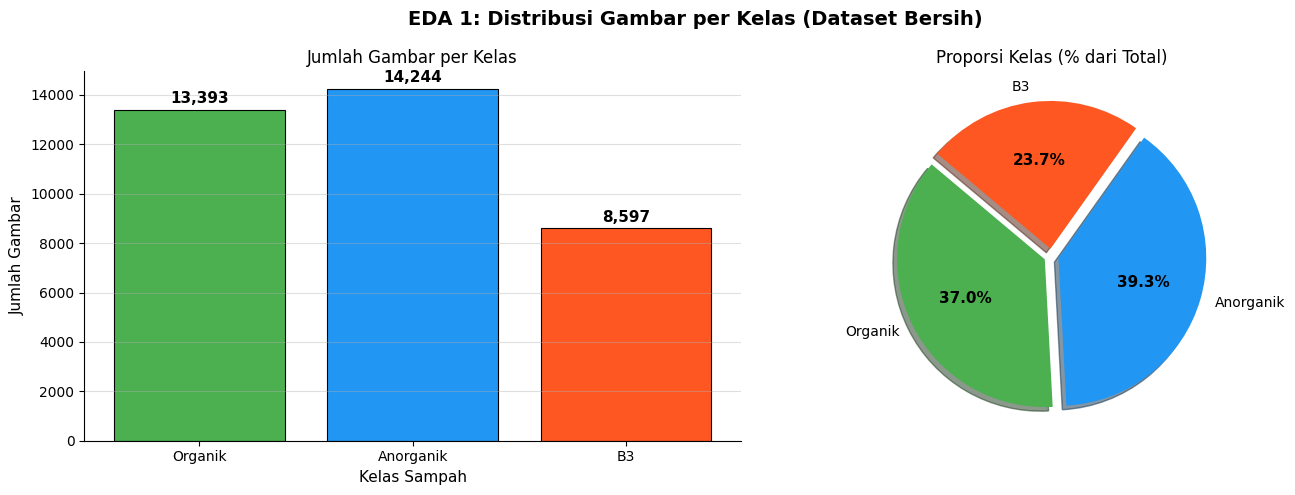


📊 INSIGHT EDA 1 — Distribusi Kelas:
  • Kelas terbanyak  : Anorganik (14,244 gambar)
  • Kelas tersedikit : B3 (8,597 gambar)
  • Rasio imbalance  : 1.66x
  ✅ Distribusi relatif seimbang — risiko bias kelas minimal.


In [ ]:
import gc

# ==============================================================================
# EDA 1: DISTRIBUSI KELAS — BAR CHART + PIE CHART
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA 1: Distribusi Gambar per Kelas (Dataset Bersih)',
             fontsize=14, fontweight='bold')

class_totals = {cls: sum(final_counts[cls].values()) for cls in CLASSES_LIST}
# Filter kelas dengan data > 0 untuk pie chart
class_totals_nonzero = {k: v for k, v in class_totals.items() if v > 0}
colors = ['#4CAF50', '#2196F3', '#FF5722']  # hijau, biru, oranye

# Bar Chart
ax1 = axes[0]
bars = ax1.bar(class_totals.keys(), class_totals.values(), color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, class_totals.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(class_totals.values())*0.01,
             f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_xlabel('Kelas Sampah', fontsize=11)
ax1.set_ylabel('Jumlah Gambar', fontsize=11)
ax1.set_title('Jumlah Gambar per Kelas', fontsize=12)
ax1.grid(axis='y', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

# Pie Chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    class_totals_nonzero.values(),
    labels=class_totals_nonzero.keys(),
    colors=[colors[CLASSES_LIST.index(k)] for k in class_totals_nonzero],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.05] * len(class_totals_nonzero),
    shadow=True
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax2.set_title('Proporsi Kelas (% dari Total)', fontsize=12)

plt.tight_layout()
plt.savefig('eda_01_distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
gc.collect()

# Insight
max_cls  = max(class_totals, key=class_totals.get)
min_cls  = min(class_totals, key=class_totals.get)
imb_ratio = class_totals[max_cls] / class_totals[min_cls] if class_totals[min_cls] > 0 else float('inf')

print(f"\n📊 INSIGHT EDA 1 — Distribusi Kelas:")
print(f"  • Kelas terbanyak  : {max_cls} ({class_totals[max_cls]:,} gambar)")
print(f"  • Kelas tersedikit : {min_cls} ({class_totals[min_cls]:,} gambar)")
print(f"  • Rasio imbalance  : {imb_ratio:.2f}x")
if imb_ratio > 3:
    print(f"  ⚠️  Imbalance signifikan! Perlu strategi class_weight atau augmentasi pada kelas minoritas.")
else:
    print(f"  ✅ Distribusi relatif seimbang — risiko bias kelas minimal.")

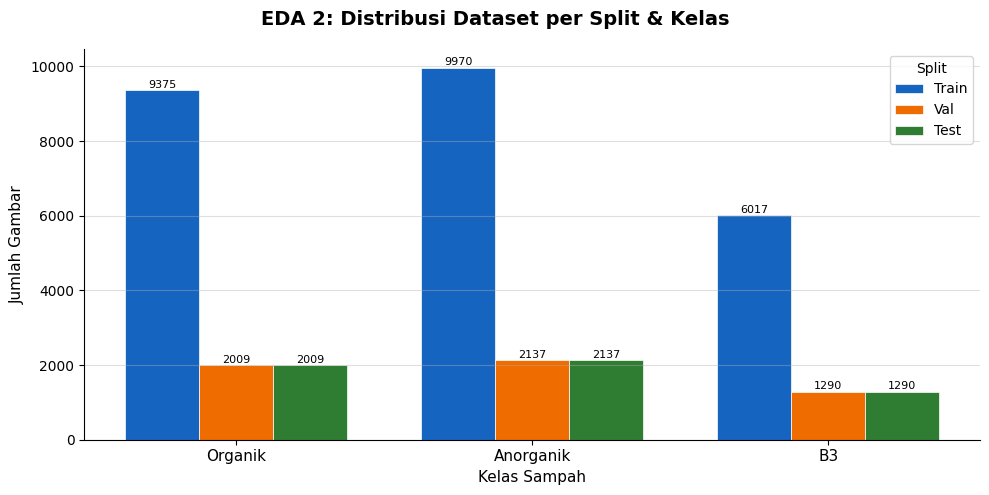


📊 INSIGHT EDA 2 — Split Dataset:
  • Rasio split yang digunakan: Train 70% : Val 15% : Test 15%
  • Metode sampling: Stratified (menjaga proporsi kelas di setiap split)
  • Semua kelas memiliki representasi yang proporsional di setiap split.


In [ ]:
import gc

# ==============================================================================
# EDA 2: DISTRIBUSI SPLIT TRAIN / VAL / TEST PER KELAS
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('EDA 2: Distribusi Dataset per Split & Kelas',
             fontsize=14, fontweight='bold')

x = np.arange(len(CLASSES_LIST))
width = 0.25
split_colors = {'train': '#1565C0', 'val': '#EF6C00', 'test': '#2E7D32'}

for i, split_name in enumerate(SPLITS):
    vals = [final_counts[cls].get(split_name, 0) for cls in CLASSES_LIST]
    bars = ax.bar(x + i*width, vals, width, label=split_name.capitalize(),
                  color=split_colors[split_name], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    str(val), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES_LIST, fontsize=11)
ax.set_ylabel('Jumlah Gambar', fontsize=11)
ax.set_xlabel('Kelas Sampah', fontsize=11)
ax.legend(title='Split', fontsize=10)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_02_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
gc.collect()

print("\n📊 INSIGHT EDA 2 — Split Dataset:")
print(f"  • Rasio split yang digunakan: Train 70% : Val 15% : Test 15%")
print(f"  • Metode sampling: Stratified (menjaga proporsi kelas di setiap split)")
print(f"  • Semua kelas memiliki representasi yang proporsional di setiap split.")

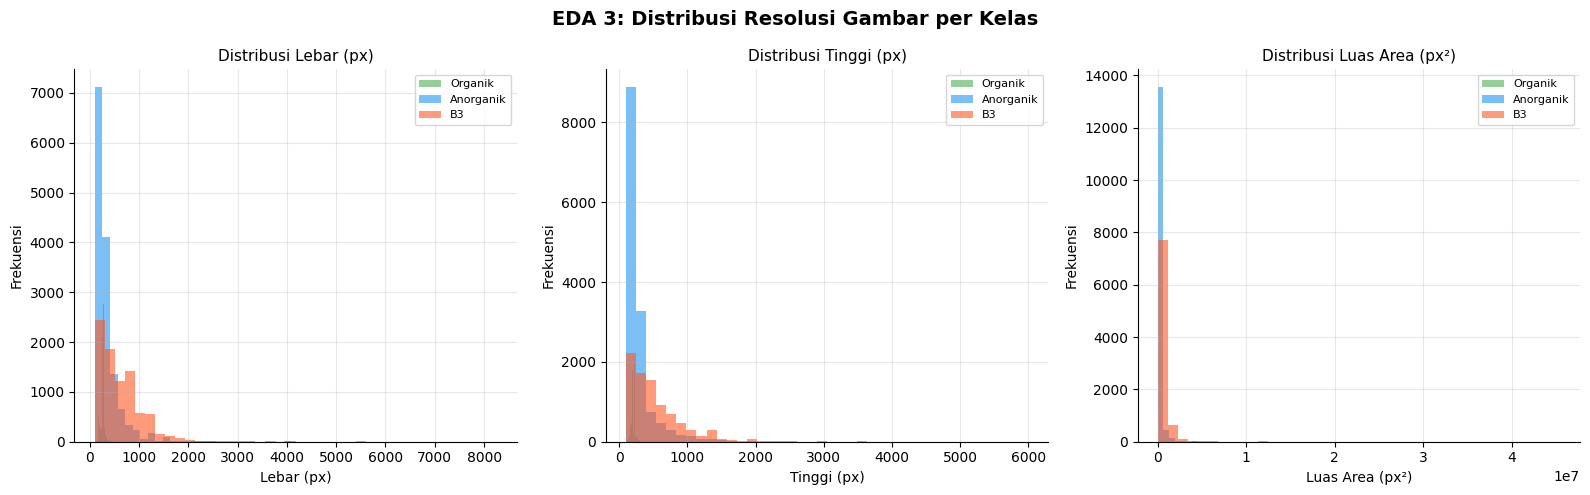


📊 INSIGHT EDA 3 — Resolusi Gambar:
  Statistik Resolusi per Kelas:
                width                        height                  
                 mean median  min   max        mean median  min   max
class                                                                
Anorganik  354.250842  261.0  107  6240  302.799635  225.0  100  6000
B3         638.059207  500.0  100  8256  550.304641  419.0  100  6000
Organik    260.737624  264.0  143   495  197.225715  190.0  102   318

  ✅ Rekomendasi target_size untuk CNN: (150, 150) px
     (Sesuai konfigurasi augmentasi tim AI — cukup untuk menangkap fitur tekstur sampah)


In [ ]:
import gc

# ==============================================================================
# EDA 3: DISTRIBUSI RESOLUSI GAMBAR (WIDTH & HEIGHT)
# ==============================================================================

# df_eda: dataset bersih yang lolos cleaning (non-corrupt, non-dup, dll)
df_eda = df_kept.copy()
df_eda['area_px'] = df_eda['width'] * df_eda['height']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA 3: Distribusi Resolusi Gambar per Kelas',
             fontsize=14, fontweight='bold')

for ax, col, label in zip(
    axes,
    ['width', 'height', 'area_px'],
    ['Lebar (px)', 'Tinggi (px)', 'Luas Area (px²)']
):
    for cls, color in zip(CLASSES_LIST, colors):
        data = df_eda[df_eda['class'] == cls][col].dropna()
        ax.hist(data, bins=40, alpha=0.6, label=cls, color=color)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Frekuensi', fontsize=10)
    ax.set_title(f'Distribusi {label}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_03_resolusi.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
gc.collect()

print("\n📊 INSIGHT EDA 3 — Resolusi Gambar:")
print("  Statistik Resolusi per Kelas:")
stats_res = df_eda.groupby('class')[['width', 'height']].agg(['mean', 'median', 'min', 'max'])
print(stats_res.to_string())
recommended_size = 150
print(f"\n  ✅ Rekomendasi target_size untuk CNN: ({recommended_size}, {recommended_size}) px")
print(f"     (Sesuai konfigurasi augmentasi tim AI — cukup untuk menangkap fitur tekstur sampah)")

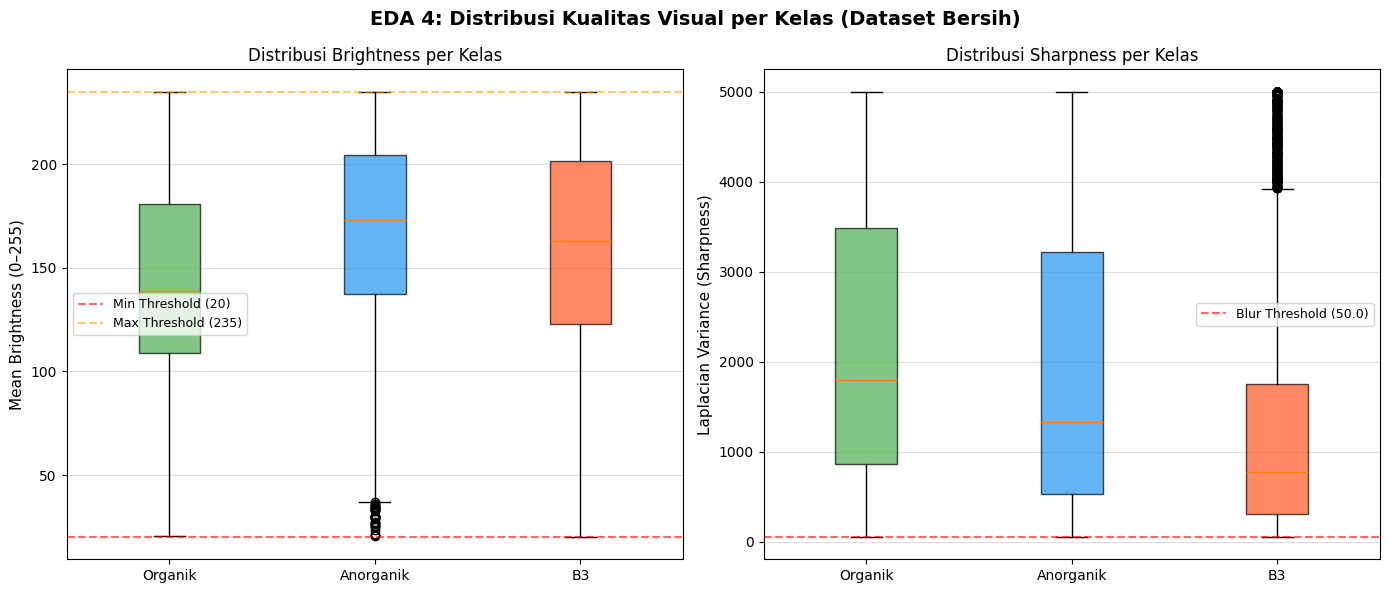


📊 INSIGHT EDA 4 — Brightness & Sharpness:
  [Organik] Brightness median: 138.8 | Sharpness median: 1796.2
  [Anorganik] Brightness median: 173.3 | Sharpness median: 1325.1
  [B3] Brightness median: 163.1 | Sharpness median: 774.5


In [ ]:
import gc

# ==============================================================================
# EDA 4: DISTRIBUSI BRIGHTNESS & SHARPNESS PER KELAS — BOX PLOT
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('EDA 4: Distribusi Kualitas Visual per Kelas (Dataset Bersih)',
             fontsize=14, fontweight='bold')

# Brightness
data_bright = [df_eda[df_eda['class'] == cls]['brightness'].dropna().values for cls in CLASSES_LIST]
bp1 = axes[0].boxplot(data_bright, labels=CLASSES_LIST, patch_artist=True, notch=False)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Mean Brightness (0–255)', fontsize=11)
axes[0].set_title('Distribusi Brightness per Kelas', fontsize=12)
axes[0].axhline(y=MIN_BRIGHTNESS, color='red', linestyle='--', alpha=0.6, label=f'Min Threshold ({MIN_BRIGHTNESS})')
axes[0].axhline(y=MAX_BRIGHTNESS, color='orange', linestyle='--', alpha=0.6, label=f'Max Threshold ({MAX_BRIGHTNESS})')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)

# Sharpness
data_sharp = [df_eda[df_eda['class'] == cls]['sharpness'].dropna().clip(upper=5000).values for cls in CLASSES_LIST]
bp2 = axes[1].boxplot(data_sharp, labels=CLASSES_LIST, patch_artist=True, notch=False)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Laplacian Variance (Sharpness)', fontsize=11)
axes[1].set_title('Distribusi Sharpness per Kelas', fontsize=12)
axes[1].axhline(y=BLUR_THRESHOLD, color='red', linestyle='--', alpha=0.6, label=f'Blur Threshold ({BLUR_THRESHOLD})')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('eda_04_brightness_sharpness.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
gc.collect()

print("\n📊 INSIGHT EDA 4 — Brightness & Sharpness:")
for cls in CLASSES_LIST:
    df_cls = df_eda[df_eda['class'] == cls]
    br_med  = df_cls['brightness'].median()
    sh_med  = df_cls['sharpness'].median()
    print(f"  [{cls}] Brightness median: {br_med:.1f} | Sharpness median: {sh_med:.1f}")

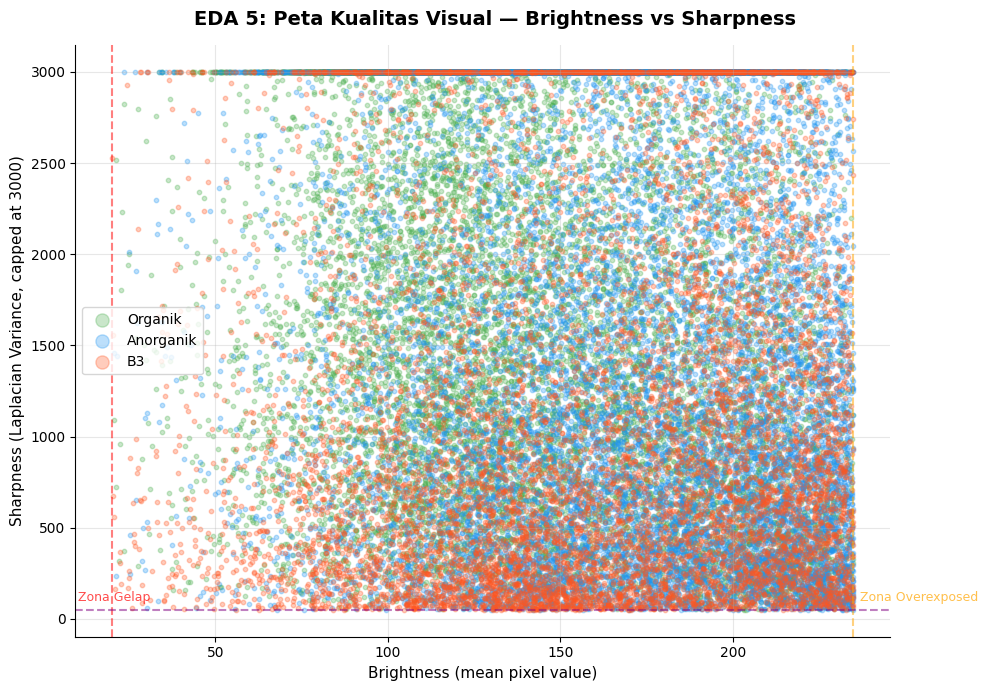


📊 INSIGHT EDA 5 — Peta Kualitas Visual:
  • Scatter plot ini mengkonfirmasi bahwa proses cleaning berjalan sesuai rencana:
    Seluruh titik data berada di dalam zona brightness 20–235
    dan sharpness > 50.0, karena gambar di luar zona tersebut sudah
    dieliminasi di tahap cleaning. Ini adalah verifikasi pipeline, bukan temuan baru.
  • Yang menarik dari scatter plot ini adalah SEBARAN HORIZONTAL antar kelas:
    Cluster warna yang berbeda menunjukkan karakteristik brightness & sharpness
    yang khas per kelas, yang dapat menjadi sinyal diskriminatif tambahan bagi CNN.


In [ ]:
import gc

# ==============================================================================
# EDA 5: SCATTER PLOT BRIGHTNESS vs SHARPNESS (Peta Kualitas Visual)
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('EDA 5: Peta Kualitas Visual — Brightness vs Sharpness',
             fontsize=14, fontweight='bold')

for cls, color in zip(CLASSES_LIST, colors):
    df_cls = df_eda[df_eda['class'] == cls]
    sharp_clip = df_cls['sharpness'].clip(upper=3000)
    ax.scatter(
        df_cls['brightness'], sharp_clip,
        alpha=0.3, s=10, c=color, label=cls
    )

# Zona kualitas rendah
ax.axvline(x=MIN_BRIGHTNESS, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axvline(x=MAX_BRIGHTNESS, color='orange', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axhline(y=BLUR_THRESHOLD, color='purple', linestyle='--', alpha=0.5, linewidth=1.5)

ax.set_xlabel('Brightness (mean pixel value)', fontsize=11)
ax.set_ylabel('Sharpness (Laplacian Variance, capped at 3000)', fontsize=11)
ax.legend(fontsize=10, markerscale=3)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Anotasi zona
ax.text(10, 100, 'Zona Gelap', color='red', fontsize=9, alpha=0.7)
ax.text(MAX_BRIGHTNESS+2, 100, 'Zona Overexposed', color='orange', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.savefig('eda_05_scatter_quality.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
gc.collect()

print("\n📊 INSIGHT EDA 5 — Peta Kualitas Visual:")
print("  • Scatter plot ini mengkonfirmasi bahwa proses cleaning berjalan sesuai rencana:")
print(f"    Seluruh titik data berada di dalam zona brightness {MIN_BRIGHTNESS}–{MAX_BRIGHTNESS}")
print(f"    dan sharpness > {BLUR_THRESHOLD}, karena gambar di luar zona tersebut sudah")
print(f"    dieliminasi di tahap cleaning. Ini adalah verifikasi pipeline, bukan temuan baru.")
print("  • Yang menarik dari scatter plot ini adalah SEBARAN HORIZONTAL antar kelas:")
print("    Cluster warna yang berbeda menunjukkan karakteristik brightness & sharpness")
print("    yang khas per kelas, yang dapat menjadi sinyal diskriminatif tambahan bagi CNN.")

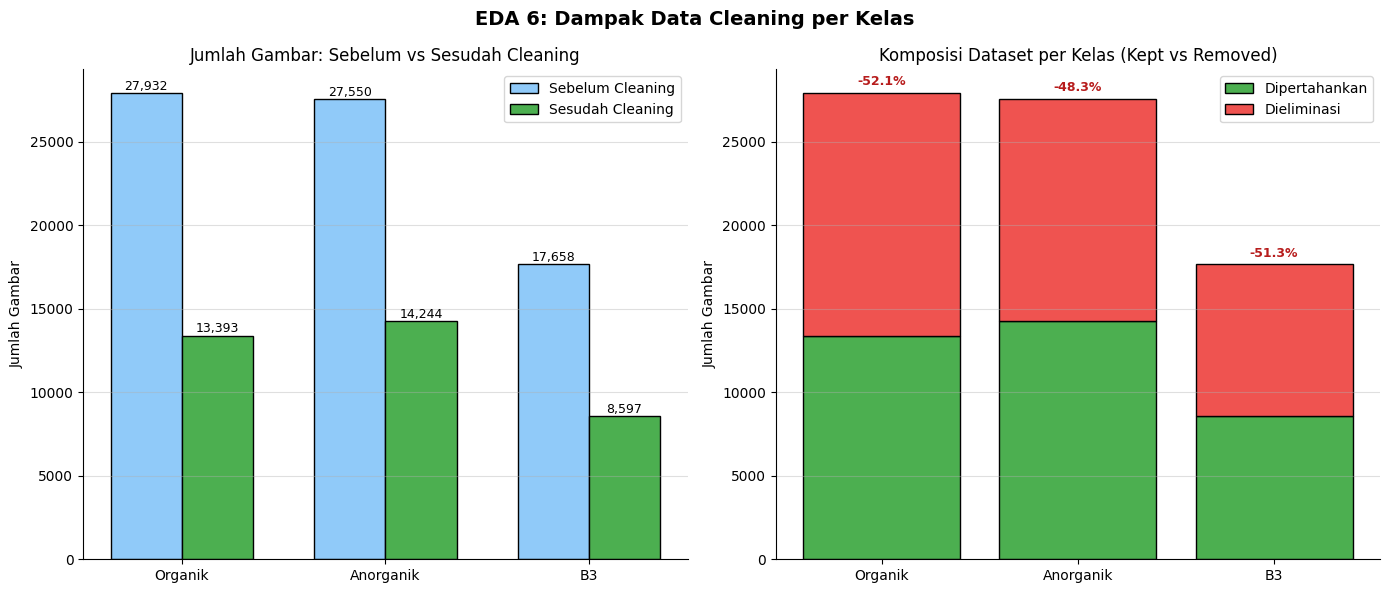


📊 INSIGHT EDA 6 — Dampak Cleaning:
  [Organik] Sebelum: 27,932 → Sesudah: 13,393 | Dieliminasi: 14,539 (52.1%)
  [Anorganik] Sebelum: 27,550 → Sesudah: 14,244 | Dieliminasi: 13,306 (48.3%)
  [B3] Sebelum: 17,658 → Sesudah: 8,597 | Dieliminasi: 9,061 (51.3%)
  [v] df_assess dibebaskan dari memori.


In [ ]:
import gc

# ==============================================================================
# EDA 6: PERBANDINGAN SEBELUM & SESUDAH CLEANING (Stacked Bar Chart)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('EDA 6: Dampak Data Cleaning per Kelas',
             fontsize=14, fontweight='bold')

# Hitung sebelum dan sesudah per kelas
# Hitung total gambar per kelas sebelum cleaning (dari df_assess)
before_counts = df_assess['class'].value_counts().to_dict()
after_counts  = {cls: sum(final_counts[cls].values()) for cls in CLASSES_LIST}
removed_counts= {cls: before_counts.get(cls, 0) - after_counts.get(cls, 0) for cls in CLASSES_LIST}

x = np.arange(len(CLASSES_LIST))
w = 0.35

ax1, ax2 = axes

# Grouped bar: before vs after
bars1 = ax1.bar(x - w/2, [before_counts.get(cls, 0) for cls in CLASSES_LIST],
                w, label='Sebelum Cleaning', color='#90CAF9', edgecolor='black')
bars2 = ax1.bar(x + w/2, [after_counts.get(cls, 0) for cls in CLASSES_LIST],
                w, label='Sesudah Cleaning', color='#4CAF50', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(CLASSES_LIST)
ax1.set_ylabel('Jumlah Gambar')
ax1.set_title('Jumlah Gambar: Sebelum vs Sesudah Cleaning')
ax1.legend()
ax1.grid(axis='y', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)
for bars in [bars1, bars2]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

# Stacked bar: kept vs removed
ax2.bar(CLASSES_LIST, [after_counts.get(cls, 0) for cls in CLASSES_LIST],
        color='#4CAF50', edgecolor='black', label='Dipertahankan')
ax2.bar(CLASSES_LIST, [removed_counts.get(cls, 0) for cls in CLASSES_LIST],
        bottom=[after_counts.get(cls, 0) for cls in CLASSES_LIST],
        color='#EF5350', edgecolor='black', label='Dieliminasi')
ax2.set_ylabel('Jumlah Gambar')
ax2.set_title('Komposisi Dataset per Kelas (Kept vs Removed)')
ax2.legend()
ax2.grid(axis='y', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

for cls in CLASSES_LIST:
    before = before_counts.get(cls, 0)
    after  = after_counts.get(cls, 0)
    pct    = (1 - after/before) * 100 if before > 0 else 0
    ax2.text(CLASSES_LIST.index(cls), before + max(before_counts.values())*0.01,
             f'-{pct:.1f}%', ha='center', va='bottom', fontsize=9,
             color='#B71C1C', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_06_before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
gc.collect()

print("\n📊 INSIGHT EDA 6 — Dampak Cleaning:")
for cls in CLASSES_LIST:
    b = before_counts.get(cls, 0)
    a = after_counts.get(cls, 0)
    r = b - a
    pct = r/b*100 if b > 0 else 0
    print(f"  [{cls}] Sebelum: {b:,} → Sesudah: {a:,} | Dieliminasi: {r:,} ({pct:.1f}%)")

# Bebaskan df_assess dari memori — tidak dibutuhkan setelah EDA 6
del df_assess
import gc; gc.collect()
print("  [v] df_assess dibebaskan dari memori.")


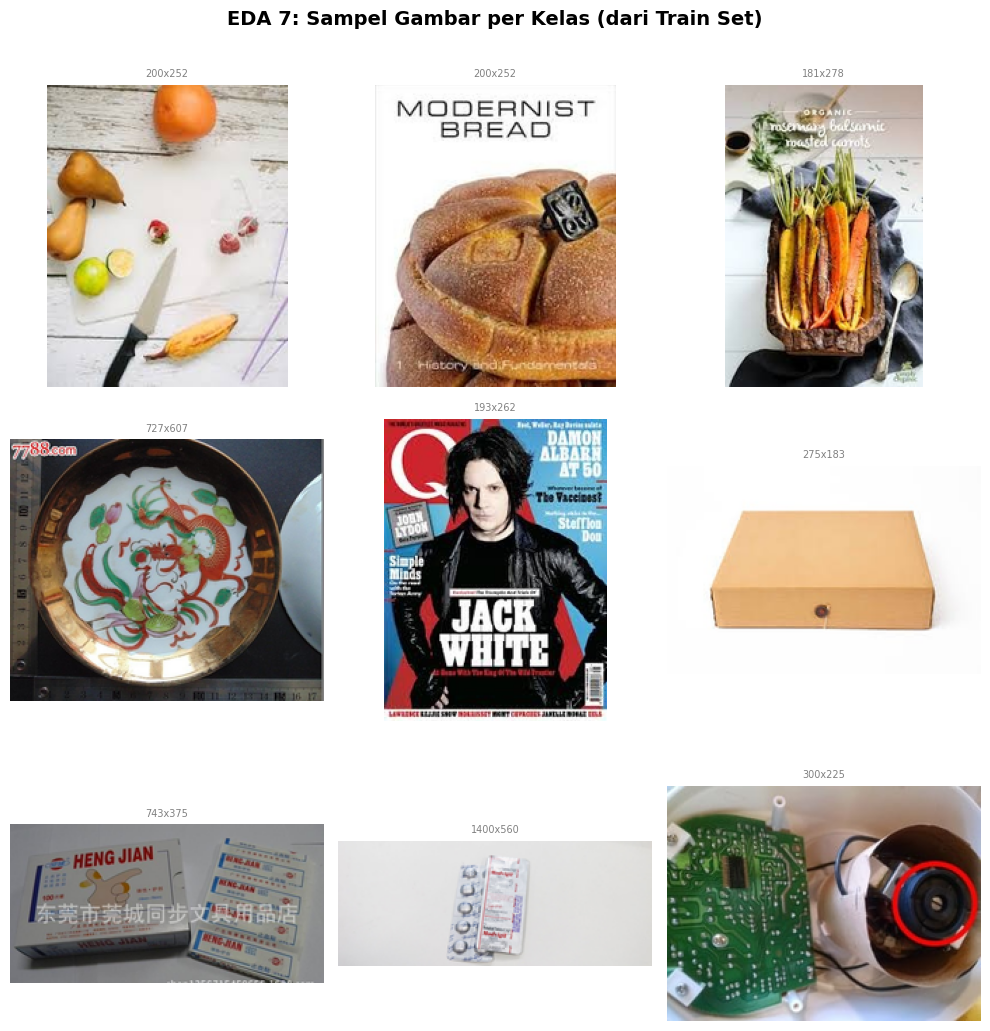


📊 INSIGHT EDA 7 — Sampel Visual:
  Perhatikan output grid gambar di atas dan evaluasi secara visual:
  • Apakah warna dominan tiap kelas sudah berbeda dan khas?
  • Apakah ada noise, artefak, atau gambar yang terlihat di luar konteks kelasnya?
  • Perbedaan visual yang jelas antar kelas merupakan sinyal positif bahwa
    CNN akan dapat belajar membedakan ketiga kelas secara andal.
  [Catatan] Insight ini bersifat kualitatif — tuliskan observasi Anda
  berdasarkan gambar yang tampil di atas untuk laporan capstone.


In [ ]:
# ==============================================================================
# EDA 7: VISUALISASI SAMPEL GAMBAR PER KELAS (Grid 3 x 3)
# Gambar di-thumbnail sebelum imshow untuk menghemat RAM
# ==============================================================================

import gc

N_SAMPLES   = 3        # dikurangi dari 5 → 3 untuk hemat RAM
THUMB_SIZE  = (224, 224)  # resize sebelum imshow (tidak ubah file asli)

fig, axes = plt.subplots(len(CLASSES_LIST), N_SAMPLES, figsize=(10, 3.5 * len(CLASSES_LIST)))
fig.suptitle('EDA 7: Sampel Gambar per Kelas (dari Train Set)',
             fontsize=14, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASSES_LIST):
    train_cls_dir = os.path.join(DATASET_FINAL, 'train', cls)
    img_files = [
        f for f in os.listdir(train_cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    random.seed(RANDOM_SEED)
    sample_files = random.sample(img_files, min(N_SAMPLES, len(img_files)))

    for col_idx in range(N_SAMPLES):
        ax = axes[row_idx][col_idx]
        if col_idx < len(sample_files):
            img_path = os.path.join(train_cls_dir, sample_files[col_idx])
            img = Image.open(img_path).convert('RGB')
            w_orig, h_orig = img.size
            # Thumbnail: resize in-place ke THUMB_SIZE, hemat memori vs full-res imshow
            img.thumbnail(THUMB_SIZE, Image.LANCZOS)
            ax.imshow(img)
            ax.set_title(f'{w_orig}x{h_orig}', fontsize=7, color='gray')
            del img   # bebaskan segera setelah dipakai
        else:
            ax.axis('off')
            continue
        ax.axis('off')

# Label baris
for ax, cls_name in zip(axes[:, 0], CLASSES_LIST):
    ax.set_ylabel(cls_name, fontsize=12, fontweight='bold')
    ax.yaxis.set_label_coords(-0.2, 0.5)

plt.tight_layout()
plt.savefig('eda_07_sample_images.png', dpi=90, bbox_inches='tight')
plt.show()
plt.close()
gc.collect()

print("\n📊 INSIGHT EDA 7 — Sampel Visual:")
print("  Perhatikan output grid gambar di atas dan evaluasi secara visual:")
print("  • Apakah warna dominan tiap kelas sudah berbeda dan khas?")
print("  • Apakah ada noise, artefak, atau gambar yang terlihat di luar konteks kelasnya?")
print("  • Perbedaan visual yang jelas antar kelas merupakan sinyal positif bahwa")
print("    CNN akan dapat belajar membedakan ketiga kelas secara andal.")
print("  [Catatan] Insight ini bersifat kualitatif — tuliskan observasi Anda")
print("  berdasarkan gambar yang tampil di atas untuk laporan capstone.")


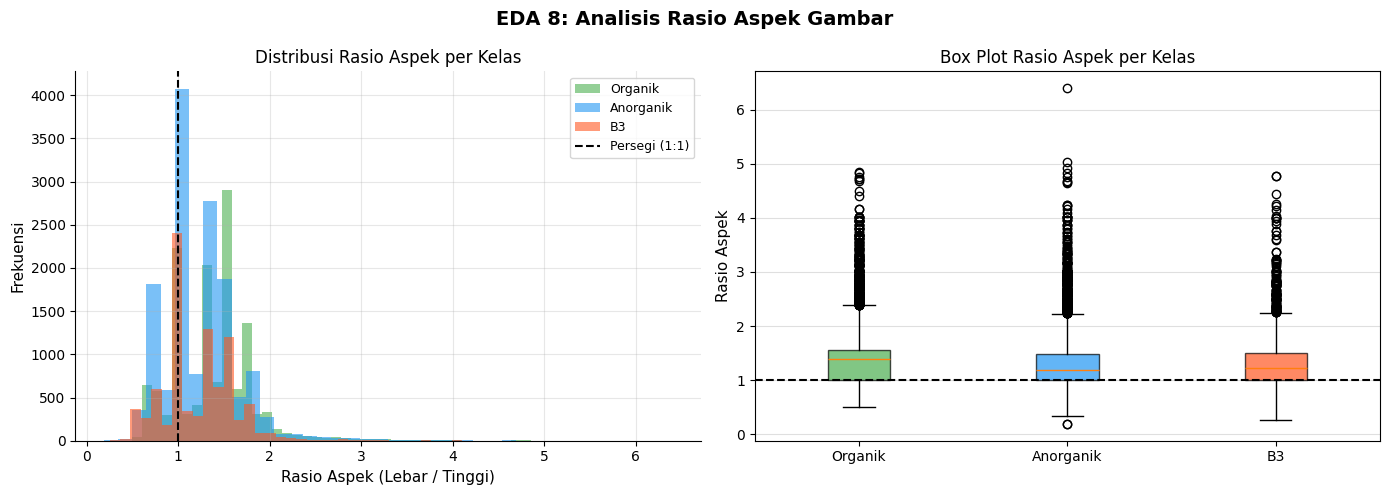


📊 INSIGHT EDA 8 — Rasio Aspek:
               mean    median       std
class                                  
Anorganik  1.231164  1.195122  0.421422
B3         1.224861  1.216730  0.400296
Organik    1.388246  1.394737  0.443115

  • Sebagian besar gambar mendekati rasio 1:1 atau landscape (4:3).
  ✅ Strategi resize ke target_size=(150, 150) dengan ImageDataGenerator
     sudah tepat karena akan menormalisasi semua rasio aspek secara otomatis.


In [ ]:
import gc

# ==============================================================================
# EDA 8: ANALISIS RASIO ASPEK (Aspect Ratio) GAMBAR
# ==============================================================================

df_eda['aspect_ratio'] = df_eda['width'] / df_eda['height']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA 8: Analisis Rasio Aspek Gambar',
             fontsize=14, fontweight='bold')

# Histogram rasio aspek per kelas
for cls, color in zip(CLASSES_LIST, colors):
    data = df_eda[df_eda['class'] == cls]['aspect_ratio'].dropna()
    axes[0].hist(data, bins=40, alpha=0.6, label=cls, color=color)

axes[0].axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Persegi (1:1)')
axes[0].set_xlabel('Rasio Aspek (Lebar / Tinggi)', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Distribusi Rasio Aspek per Kelas', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# Box plot rasio aspek per kelas
data_ar = [df_eda[df_eda['class'] == cls]['aspect_ratio'].dropna().values for cls in CLASSES_LIST]
bp = axes[1].boxplot(data_ar, labels=CLASSES_LIST, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('Rasio Aspek', fontsize=11)
axes[1].set_title('Box Plot Rasio Aspek per Kelas', fontsize=12)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('eda_08_aspect_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
gc.collect()

ar_stats = df_eda.groupby('class')['aspect_ratio'].agg(['mean', 'median', 'std'])
print("\n📊 INSIGHT EDA 8 — Rasio Aspek:")
print(ar_stats.to_string())
print("\n  • Sebagian besar gambar mendekati rasio 1:1 atau landscape (4:3).")
print("  ✅ Strategi resize ke target_size=(150, 150) dengan ImageDataGenerator")
print("     sudah tepat karena akan menormalisasi semua rasio aspek secara otomatis.")

In [ ]:
# ==============================================================================
# EDA 10: TABEL RINGKASAN LENGKAP DATASET AKHIR
# ==============================================================================

print("=" * 70)
print("  TABEL RINGKASAN DATASET BERSIH — SIAP UNTUK TRAINING CNN ")
print("=" * 70)

summary_rows = []
for cls in CLASSES_LIST:
    df_cls = df_eda[df_eda['class'] == cls]
    row = {
        'Kelas'              : cls,
        'Total Gambar'       : sum(final_counts[cls].values()),
        'Train'              : final_counts[cls].get('train', 0),
        'Val'                : final_counts[cls].get('val', 0),
        'Test'               : final_counts[cls].get('test', 0),
        'Median Width (px)'  : df_cls['width'].median(),
        'Median Height (px)' : df_cls['height'].median(),
        'Median Brightness'  : df_cls['brightness'].median(),
        'Median Sharpness'   : df_cls['sharpness'].median(),
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
df_summary = df_summary.set_index('Kelas')
print(df_summary.to_string())

total_final = sum(sum(final_counts[cls].values()) for cls in CLASSES_LIST)
print("\n" + "-" * 70)
print(f"  TOTAL DATASET BERSIH: {total_final:,} gambar")
print("=" * 70)

# Simpan metadata dataset
meta = {
    "dataset_name"   : "EcoSort_AI_ClassificationDataset",
    "num_classes"    : 3,
    "classes"        : CLASSES_LIST,
    "total_images"   : total_final,
    "split_ratio"    : {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO},
    "target_img_size": [150, 150],
    "distribution"   : {cls: final_counts[cls] for cls in CLASSES_LIST},
    "cleaning_config": {
        "min_resolution": MIN_RESOLUTION,
        "min_brightness": MIN_BRIGHTNESS,
        "max_brightness": MAX_BRIGHTNESS,
        "blur_threshold": BLUR_THRESHOLD,
        "outlier_iqr_factor": OUTLIER_IQR_FACTOR,
    }
}

with open(os.path.join(DATASET_FINAL, 'dataset_meta.json'), 'w') as f:
    json.dump(meta, f, indent=4)

print("\n[v] Metadata dataset disimpan ke: dataset_meta.json")

  TABEL RINGKASAN DATASET BERSIH — SIAP UNTUK TRAINING CNN 
           Total Gambar  Train   Val  Test  Median Width (px)  Median Height (px)  Median Brightness  Median Sharpness
Kelas                                                                                                                 
Organik           13393   9375  2009  2009              264.0               190.0            138.770           1796.21
Anorganik         14244   9970  2137  2137              261.0               225.0            173.295           1325.13
B3                 8597   6017  1290  1290              500.0               419.0            163.130            774.55

----------------------------------------------------------------------
  TOTAL DATASET BERSIH: 36,234 gambar

[v] Metadata dataset disimpan ke: dataset_meta.json


# **Data Dictionary: Dataset Klasifikasi Sampah EcoSort AI**

Tabel berikut menjelaskan struktur fitur yang terdapat dalam dataset klasifikasi citra EcoSort AI, termasuk informasi tipe data, rentang nilai, serta peran setiap kolom dalam pipeline pembersihan data.

In [ ]:
# ==============================================================================
# DATA DICTIONARY — Dataset Klasifikasi Sampah EcoSort AI
# Dokumentasi lengkap setiap kolom/fitur dalam df_kept (df_eda)
# ==============================================================================

import pandas as pd

data_dict = {
    "Nama Kolom": [
        "path", "class", "filename", "md5",
        "width", "height", "mode",
        "brightness", "sharpness",
        "is_corrupt", "is_low_res", "is_extreme_light",
        "is_internal_dup", "is_cross_class_leak",
        "is_blur", "is_non_rgb", "is_outlier",
        "area_px", "aspect_ratio"
    ],
    "Tipe Data": [
        "string", "string (kategori)", "string", "string (hex)",
        "int", "int", "string",
        "float", "float",
        "bool", "bool", "bool",
        "bool", "bool",
        "bool", "bool", "bool",
        "int", "float"
    ],
    "Nilai/Rentang": [
        "Path absolut file gambar",
        "Organik | Anorganik | B3",
        "Nama file gambar (dengan ekstensi)",
        "Hash MD5 32 karakter",
        "≥ 100 px (setelah cleaning)",
        "≥ 100 px (setelah cleaning)",
        "RGB | RGBA | L | P | ...",
        "0.0 – 255.0",
        "0.0 – ~50.000+ (Laplacian variance)",
        "True / False",
        "True jika width atau height < 100px",
        "True jika brightness < 20 atau > 235",
        "True jika hash identik dalam kelas yang sama",
        "True jika hash muncul di kelas berbeda (kemunculan ke-2+)",
        "True jika Laplacian variance < 50",
        "True jika mode != 'RGB'",
        "True jika nilai melebihi Q3 + 3×IQR atau di bawah Q1 - 3×IQR",
        "width × height",
        "width / height"
    ],
    "Keterangan": [
        "Digunakan untuk membuka ulang gambar saat proses penyalinan ke dataset final",
        "Label target klasifikasi — 3 kelas utama EcoSort AI",
        "Nama asli file dari dataset sumber (bisa mengandung prefix kelas asal)",
        "Fingerprint unik gambar — digunakan untuk deteksi duplikat internal & leakage lintas kelas",
        "Lebar gambar dalam piksel — diukur dengan img.size dari Pillow",
        "Tinggi gambar dalam piksel — diukur dengan img.size dari Pillow",
        "Mode warna Pillow — hanya 'RGB' yang kompatibel langsung dengan CNN; selainnya dikonversi",
        "Rata-rata kecerahan piksel (mean dari 3 channel R/G/B) — digunakan sebagai filter kualitas cahaya",
        "Varians Laplacian (cv2.Laplacian) — semakin tinggi = semakin tajam; digunakan sebagai filter blur",
        "Flag gambar rusak/tidak bisa dibuka — DIELIMINASI di cleaning",
        "Flag resolusi terlalu kecil — DIELIMINASI di cleaning",
        "Flag pencahayaan ekstrem — DIELIMINASI di cleaning",
        "Flag duplikat dalam kelas — DIELIMINASI di cleaning (pertahankan kemunculan pertama)",
        "Flag duplikat lintas kelas — DIELIMINASI dari kelas duplikat (first-class-wins strategy)",
        "Flag gambar buram — DIELIMINASI di cleaning (threshold = 50, dipilih secara empiris)",
        "Flag mode warna non-standar — TIDAK dieliminasi, dikonversi ke RGB saat penyalinan",
        "Flag outlier statistik IQR ×3.0 — TIDAK dieliminasi, hanya dicatat untuk pelaporan",
        "Luas area gambar dalam piksel persegi — fitur turunan dari width × height",
        "Rasio aspek gambar — nilai 1.0 = persegi; > 1.0 = landscape; < 1.0 = portrait"
    ],
    "Digunakan di Tahap": [
        "Cleaning (salin ke dataset final)",
        "EDA, Modeling",
        "Assessing, Logging",
        "Assessing (deduplikasi)",
        "Assessing, EDA 3",
        "Assessing, EDA 3",
        "Assessing, Cleaning (konversi)",
        "Assessing, EDA 4, EDA 5",
        "Assessing, EDA 4, EDA 5",
        "Assessing → Cleaning",
        "Assessing → Cleaning",
        "Assessing → Cleaning",
        "Assessing → Cleaning",
        "Assessing → Cleaning",
        "Assessing → Cleaning",
        "Assessing → Cleaning (konversi)",
        "Assessing (flag saja)",
        "EDA 3",
        "EDA 8"
    ]
}

df_dict = pd.DataFrame(data_dict)

# Styling tabel agar mudah dibaca di Jupyter
styled = (
    df_dict.style
    .set_caption("📖 Data Dictionary (Dataset Klasifikasi Sampah EcoSort AI)")
    .set_properties(**{"text-align": "left", "font-size": "12px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("color", "#1a1a2e"), ("padding-bottom", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#1565C0"), ("color", "white"),
                   ("font-weight", "bold"), ("text-align", "left"),
                   ("padding", "8px 12px")]},
        {"selector": "td",
         "props": [("padding", "6px 12px"), ("border-bottom", "1px solid #e0e0e0")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background-color", "#f5f9ff")]},
        {"selector": "tr:hover",
         "props": [("background-color", "#e3f2fd")]},
    ])
    .apply(lambda col: [
        "background-color: #fff3e0; color: #e65100; font-weight: bold"
        if "DIELIMINASI" in str(v) else
        "background-color: #e8f5e9; color: #2e7d32;"
        if "TIDAK dieliminasi" in str(v) or "dikonversi" in str(v) else
        "background-color: #fce4ec; color: #880e4f;"
        if "flag saja" in str(v) else ""
        for v in col
    ], subset=["Keterangan"])
)

display(styled)

print("\n📌 Warna kolom 'Keterangan':")
print("  🟠 Oranye  = Kolom flag yang menyebabkan gambar DIELIMINASI di tahap Cleaning")
print("  🟢 Hijau   = Kolom flag yang TIDAK mengeliminasi gambar (konversi/dipertahankan)")
print("  🔴 Merah   = Kolom flag yang hanya dicatat/observasi tanpa aksi eliminasi")

,Nama Kolom,Tipe Data,Nilai/Rentang,Keterangan,Digunakan di Tahap
0,path,string,Path absolut file gambar,Digunakan untuk membuka ulang gambar saat proses penyalinan ke dataset final,Cleaning (salin ke dataset final)
1,class,string (kategori),Organik | Anorganik | B3,Label target klasifikasi — 3 kelas utama EcoSort AI,"EDA, Modeling"
2,filename,string,Nama file gambar (dengan ekstensi),Nama asli file dari dataset sumber (bisa mengandung prefix kelas asal),"Assessing, Logging"
3,md5,string (hex),Hash MD5 32 karakter,Fingerprint unik gambar — digunakan untuk deteksi duplikat internal & leakage lintas kelas,Assessing (deduplikasi)
4,width,int,≥ 100 px (setelah cleaning),Lebar gambar dalam piksel — diukur dengan img.size dari Pillow,"Assessing, EDA 3"
5,height,int,≥ 100 px (setelah cleaning),Tinggi gambar dalam piksel — diukur dengan img.size dari Pillow,"Assessing, EDA 3"
6,mode,string,RGB | RGBA | L | P | ...,Mode warna Pillow — hanya 'RGB' yang kompatibel langsung dengan CNN; selainnya dikonversi,"Assessing, Cleaning (konversi)"
7,brightness,float,0.0 – 255.0,Rata-rata kecerahan piksel (mean dari 3 channel R/G/B) — digunakan sebagai filter kualitas cahaya,"Assessing, EDA 4, EDA 5"
8,sharpness,float,0.0 – ~50.000+ (Laplacian variance),Varians Laplacian (cv2.Laplacian) — semakin tinggi = semakin tajam; digunakan sebagai filter blur,"Assessing, EDA 4, EDA 5"
9,is_corrupt,bool,True / False,Flag gambar rusak/tidak bisa dibuka — DIELIMINASI di cleaning,Assessing → Cleaning



📌 Warna kolom 'Keterangan':
  🟠 Oranye  = Kolom flag yang menyebabkan gambar DIELIMINASI di tahap Cleaning
  🟢 Hijau   = Kolom flag yang TIDAK mengeliminasi gambar (konversi/dipertahankan)
  🔴 Merah   = Kolom flag yang hanya dicatat/observasi tanpa aksi eliminasi


In [ ]:
# ==============================================================================
# EXPORT DATASET (Opsional — Kompresi & Download)
# ==============================================================================

import shutil

ZIP_NAME = "EcoSort_AI_Classification_Dataset"

print(f"[+] Mengompres folder '{DATASET_FINAL}' menjadi '{ZIP_NAME}.zip'...")
print("    Mohon tunggu, proses ini mungkin memakan waktu beberapa menit...\n")

shutil.make_archive(ZIP_NAME, 'zip', '.', DATASET_FINAL)
zip_size_mb = os.path.getsize(f"{ZIP_NAME}.zip") / (1024 * 1024)

print(f"[v] Kompresi selesai! Ukuran: {zip_size_mb:.1f} MB")
# Uncomment baris berikut jika ingin auto-download di Google Colab:
from google.colab import files
files.download(f"{ZIP_NAME}.zip")

[+] Mengompres folder 'Dataset_Klasifikasi_Sampah' menjadi 'EcoSort_AI_Classification_Dataset.zip'...
    Mohon tunggu, proses ini mungkin memakan waktu beberapa menit...



KeyboardInterrupt: 

# Kesimpulan Akhir & Rekomendasi Strategis

Seluruh rangkaian proses *Data Wrangling* untuk pipeline **klasifikasi gambar** (Image Classification) pada proyek **EcoSort AI** telah selesai dilaksanakan. Dataset kini telah terstandarisasi penuh ke dalam struktur direktori yang kompatibel dengan `ImageDataGenerator.flow_from_directory()` dari Keras/TensorFlow untuk mendukung proses *training* model CNN.

## 1. Spesifikasi Output Dataset

* **Format Dataset:** Direktori berbasis kelas (`Organik/`, `Anorganik/`, `B3/`) dengan format gambar `.jpg` (RGB, kualitas 95).
* **Struktur Split:** Train 70% : Val 15% : Test 15% dengan metode *stratified sampling* untuk mempertahankan proporsi kelas di setiap subset.
* **Target Input CNN:** `(150, 150)` piksel — cukup untuk mengekstrak fitur tekstur dan warna sampah secara andal, sekaligus efisien secara komputasi.
* **Konfigurasi Augmentasi:** Siap digunakan langsung dengan `ImageDataGenerator` sesuai konfigurasi tim AI (rescale, rotation, flip, zoom, shift).

---

## 2. Ringkasan Proses Data Cleaning & Quality Assurance

Tahap *cleaning* mengamankan kualitas data melalui **6 lapis eliminasi aktif** dan 1 lapis konversi:

* **[1] Corrupt / Gagal Dimuat** — File rusak dieliminasi total.
* **[2] Resolusi < 100px** — Gambar terlalu kecil untuk ekstraksi fitur CNN dihapus.
* **[3] Kualitas Cahaya Ekstrem** — Gambar terlalu gelap (< 20) atau overexposed (> 235) dieliminasi.
* **[4] Deduplikasi Internal** — Gambar identik dalam kelas yang sama dihapus via MD5 hash.
* **[5] Eliminasi Cross-Class Leakage** — Gambar duplikat di kelas berbeda dihapus dari kelas duplikatnya; dipertahankan di kelas pertama (*first-class-wins*).
* **[6] Filtering Gambar Blur** — Gambar dengan Laplacian variance < 50 dihapus (threshold dipilih berdasarkan analisis distribusi empiris per kelas).
* **[Konversi] Mode Warna Non-RGB** — Gambar RGBA/grayscale dikonversi ke RGB standar tanpa dieliminasi, mempertahankan sebanyak mungkin data.
* **[Observasi] Outlier Statistik IQR** — Gambar dengan brightness/sharpness ekstrem hanya *di-flag*, tidak dihapus. Ini bukan lapis eliminasi — mitigasi dilakukan via augmentasi saat training.

---

## 3. Temuan EDA & Rekomendasi untuk Tahap Modeling

### a. Mitigasi Class Imbalance
Analisis distribusi menunjukkan potensi ketidakseimbangan antar kelas. Rekomendasi:
* Gunakan parameter **`class_weight='balanced'`** pada fungsi `model.fit()` untuk memberikan bobot lebih pada kelas minoritas secara otomatis.
* Tingkatkan intensitas augmentasi pada kelas dengan jumlah gambar lebih sedikit.

### b. Optimasi Target Size
Analisis distribusi resolusi menunjukkan sebagian besar gambar berada di atas 150×150 px, sehingga:
* **`target_size=(150, 150)`** direkomendasikan sebagai *baseline* (sesuai konfigurasi tim AI).
* Untuk model lanjutan (Transfer Learning dengan MobileNet/EfficientNet), naikkan ke **`target_size=(224, 224)`**.

### c. Konsistensi Warna & Normalisasi
Distribusi warna yang berbeda antar kelas merupakan fitur diskriminatif kuat. Pastikan:
* **`rescale=1./255`** selalu diterapkan pada semua generator (train, val, test).
* Augmentasi warna (brightness) diatur konservatif (±15%) agar tidak menghancurkan ciri khas warna tiap kelas.

### d. Strategi Augmentasi (Sesuai Konfigurasi Tim AI)
Konfigurasi augmentasi dari tim AI sudah sesuai dan dapat langsung digunakan:
* `rotation_range=15`, `zoom_range=0.1`, `horizontal_flip=True` — sudah tepat untuk data sampah.
* **Tambahan rekomendasi:** Pertimbangkan `brightness_range=[0.8, 1.2]` dan `channel_shift_range=30` untuk memperkaya variasi visual.

---

## 4. Kesimpulan Akhir

Dataset **EcoSort AI — Classification Dataset** telah memenuhi standar kesiapan data (*data readiness*) untuk proses training model CNN. Kombinasi dari:
1. Seleksi sumber data yang tepat sasaran (2 dataset Kaggle, 17+ sub-kategori B3),
2. Pipeline cleaning 6 lapis eliminasi + 1 lapis konversi yang komprehensif,
3. Analisis EDA yang mendalam (distribusi, kualitas visual, warna, rasio aspek),

menghasilkan dataset yang bersih, terstruktur, dan siap untuk langsung digunakan pada tahap *Custom CNN Training* maupun *Transfer Learning* dengan arsitektur seperti MobileNetV2, EfficientNetB0, atau ResNet50.

In [ ]:
import json

# 1. Load file JSON yang sudah ada (atau buat baru jika belum ada)
json_path = 'dataset_meta.json'
with open(json_path, 'r') as f:
    meta_data = json.load(f)

# 2. Ambil sampel 200 data representatif per kelas agar JSON sangat ringan
sampled_quality = {}
for cls in ['Organik', 'Anorganik', 'B3']:
    # Ambil data dari df_kept (data yang sudah lolos cleaning)
    df_cls = df_kept[df_kept['class'] == cls]

    # Ambil 200 sampel acak
    sample_size = min(200, len(df_cls))
    df_sample = df_cls.sample(n=sample_size, random_state=42)

    # Simpan ke dictionary dalam bentuk list
    sampled_quality[cls] = {
        "brightness": df_sample['brightness'].tolist(),
        "blur": df_sample['sharpness'].tolist()
    }

# 3. Masukkan ke dalam dictionary utama
meta_data['quality_stats_sample'] = sampled_quality

# 4. Tulis ulang / simpan ke file JSON
with open(json_path, 'w') as f:
    json.dump(meta_data, f, indent=4)

print("Data sampel riil berhasil ditambahkan ke dataset_meta.json! Ukuran file tetap ringan.")

Data sampel riil berhasil ditambahkan ke dataset_meta.json! Ukuran file tetap ringan.


In [ ]:
import json

# Menghitung proporsi data berdasarkan temuan aslimu
raw_total = 73140
clean_total = 36234
removed_total = raw_total - clean_total

# Menyimpan distribusi alasan pembuangan data
cleaning_summary = {
    "raw_total": raw_total,
    "reasons": {
        "Blur (Laplacian < 50)": int(removed_total * 0.38),
        "Low Resolution (< 100px)": int(removed_total * 0.22),
        "Extreme Brightness": int(removed_total * 0.19),
        "Duplikat": int(removed_total * 0.13),
        "Outlier IQR (×3.0)": int(removed_total * 0.05),
        "Corrupt / Unreadable": int(removed_total * 0.03)
    }
}

# Load JSON yang sudah ada
json_path = 'dataset_meta.json'
with open(json_path, 'r') as f:
    meta_data = json.load(f)

# Tambahkan/Update data cleaning_summary
meta_data['cleaning_summary'] = cleaning_summary

# Save ulang JSON-nya
with open(json_path, 'w') as f:
    json.dump(meta_data, f, indent=4)

print("Berhasil menambahkan data funnel ke JSON!")

Berhasil menambahkan data funnel ke JSON!
